# 🫁 Chest X-Ray Pneumonia Detection — Custom CNN vs. Transfer Learning

End-to-end **binary image classification** (NORMAL vs PNEUMONIA) designed to run
top-to-bottom on **Kaggle Notebooks (GPU P100)** — just press *Run All*.

**Clinical framing.** A missed pneumonia case (a *False Negative*) is more
dangerous than a false alarm, so **Recall / Sensitivity is the primary metric**
and **F1** is secondary.

**Pipeline.**
`EDA → Data prep (rebuilt validation split + class weights) → Custom CNN →
VGG16 transfer learning → Evaluation → Comparison → Grad-CAM → Conclusions`

All artifacts (trained `.keras` models and every figure) are written to
`/kaggle/working/`.

## 1 · Setup & Imports

Import everything, **fix all random seeds to 42** (Python, NumPy, TensorFlow) for
reproducibility, and configure the GPU. We enable *memory growth* so TensorFlow
allocates VRAM on demand instead of grabbing the whole card up front.

In [2]:
import os
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import (Input, Conv2D, BatchNormalization, Activation,
                                      MaxPooling2D, GlobalAveragePooling2D,
                                      Dense, Dropout)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (EarlyStopping, ReduceLROnPlateau,
                                        ModelCheckpoint)
from tensorflow.keras.applications import VGG16

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score)

# ---------------------------------------------------------------------------
# Reproducibility: a single SEED feeds every random operation in the notebook.
# ---------------------------------------------------------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

# ---------------------------------------------------------------------------
# GPU configuration.
# ---------------------------------------------------------------------------
gpus = tf.config.list_physical_devices("GPU")
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)
    print(f"GPU detected: {len(gpus)} device(s) -> {[g.name for g in gpus]}")
else:
    print("No GPU detected -- training will run on CPU (much slower).")

print("TensorFlow version:", tf.__version__)

2026-06-24 17:35:11.895979: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782322512.088615      59 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782322512.149363      59 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782322512.616098      59 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782322512.616140      59 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782322512.616143      59 computation_placer.cc:177] computation placer alr

GPU detected: 1 device(s) -> ['/physical_device:GPU:0']
TensorFlow version: 2.19.0


**Global configuration.** Paths point at the *read-only* Kaggle dataset; all
outputs go to `/kaggle/working/`. We standardize on **224×224×3** because the
transfer-learning backbone (VGG16) was pretrained at that resolution. X-rays are
grayscale, so we replicate the single channel to 3 channels (`color_mode="rgb"`).
A single consistent color scheme is used in every figure: **NORMAL = blue**,
**PNEUMONIA = orange/red**.

In [3]:
# ---- Dataset / output paths (Kaggle) ----
# Kaggle can mount this dataset under different roots, and it is usually
# double-nested (.../chest_xray/chest_xray/train/...). So instead of hard-coding a
# path, we SEARCH all of /kaggle/input for the folder that has BOTH train/NORMAL
# and test/NORMAL underneath it. This is robust to nesting and to the mount path.
KAGGLE_INPUT = "/kaggle/input"

def _valid_base(base):
    """A valid base dir contains both train/NORMAL and test/NORMAL."""
    return (os.path.isdir(os.path.join(base, "train", "NORMAL")) and
            os.path.isdir(os.path.join(base, "test", "NORMAL")))

def find_base_dir():
    """Locate the chest_xray base dir anywhere under /kaggle/input."""
    # Fast paths for the layouts seen most often (avoids walking the whole tree).
    for cand in [
        "/kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray",
        "/kaggle/input/chest-xray-pneumonia/chest_xray",
        "/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray",
    ]:
        if _valid_base(cand):
            return cand
    # General fallback: walk the input tree until a valid base is found.
    for cur, dirs, _ in os.walk(KAGGLE_INPUT):
        if os.path.basename(cur) == "train" and "NORMAL" in dirs and "PNEUMONIA" in dirs:
            base = os.path.dirname(cur)
            if _valid_base(base):
                return base
    raise FileNotFoundError(
        f"chest_xray dataset (train/ + test/) not found under {KAGGLE_INPUT}")

BASE_DIR   = find_base_dir()
TRAIN_DIR  = os.path.join(BASE_DIR, "train")
TEST_DIR   = os.path.join(BASE_DIR, "test")
OUTPUT_DIR = "/kaggle/working"
FIG_DIR    = os.path.join(OUTPUT_DIR, "figures")
os.makedirs(FIG_DIR, exist_ok=True)
print("Detected dataset base dir:", BASE_DIR)

# ---- Image / training constants (with rationale) ----
IMG_SIZE   = (224, 224)        # backbones (VGG16/ResNet) expect 224x224
IMG_SHAPE  = IMG_SIZE + (3,)   # 3 channels: grayscale replicated to RGB
BATCH_SIZE = 32                # fits comfortably in P100 VRAM at 224x224
CLASS_NAMES = ["NORMAL", "PNEUMONIA"]   # index 0 = NORMAL, 1 = PNEUMONIA

# ---- One consistent color scheme everywhere ----
COLOR_NORMAL    = "#1f77b4"    # blue
COLOR_PNEUMONIA = "#e8702a"    # orange / red
PALETTE = {"NORMAL": COLOR_NORMAL, "PNEUMONIA": COLOR_PNEUMONIA}

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110
print("Output figures will be saved to:", FIG_DIR)

Detected dataset base dir: /kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray
Output figures will be saved to: /kaggle/working/figures


## 2 · Dataset Exploration (EDA)

Before modeling we look at the data: how many images per class, what they look
like, and their size / intensity statistics. The headline finding is the
**~1:3 class imbalance** (NORMAL : PNEUMONIA) in the training set — if ignored, a
model can score high accuracy by simply predicting "PNEUMONIA" most of the time.

In [4]:
def list_images(directory):
    """Return absolute paths of all image files (jpeg/jpg/png) in a directory."""
    exts = (".jpeg", ".jpg", ".png")
    return [os.path.join(directory, f) for f in os.listdir(directory)
            if f.lower().endswith(exts)]

def count_by_class(split_dir):
    """Return {class_name: image_count} for a split directory."""
    return {c: len(list_images(os.path.join(split_dir, c))) for c in CLASS_NAMES}

train_counts = count_by_class(TRAIN_DIR)
test_counts  = count_by_class(TEST_DIR)

print("Train counts:", train_counts)
print("Test  counts:", test_counts)
imbalance = train_counts["PNEUMONIA"] / train_counts["NORMAL"]
print(f"Train imbalance ratio (PNEUMONIA:NORMAL) = {imbalance:.2f} : 1")

Train counts: {'NORMAL': 1341, 'PNEUMONIA': 3875}
Test  counts: {'NORMAL': 234, 'PNEUMONIA': 390}
Train imbalance ratio (PNEUMONIA:NORMAL) = 2.89 : 1


**Class distribution.** A bar chart makes the imbalance obvious at a glance.

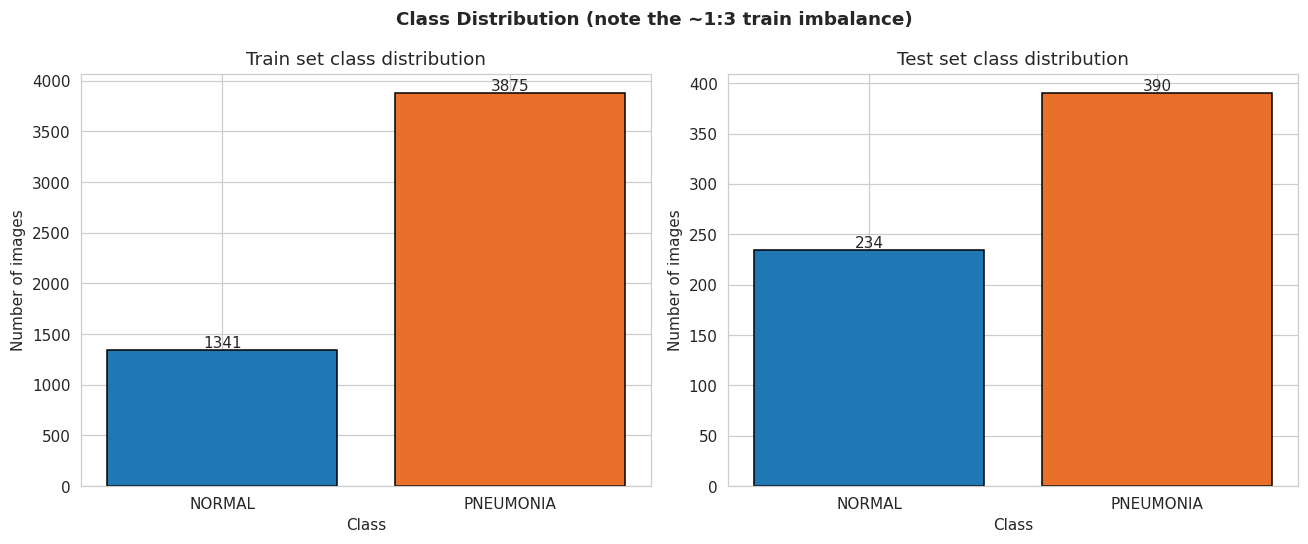

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (title, counts) in zip(axes, [("Train", train_counts), ("Test", test_counts)]):
    bars = ax.bar(list(counts.keys()), list(counts.values()),
                  color=[PALETTE[c] for c in counts.keys()], edgecolor="black")
    ax.set_title(f"{title} set class distribution")
    ax.set_xlabel("Class")
    ax.set_ylabel("Number of images")
    for b, v in zip(bars, counts.values()):
        ax.text(b.get_x() + b.get_width() / 2, v, str(v), ha="center", va="bottom")

fig.suptitle("Class Distribution (note the ~1:3 train imbalance)", fontweight="bold")
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "class_distribution.png"), bbox_inches="tight")
plt.show()

**Sample images.** A 2×4 grid (top row NORMAL, bottom row PNEUMONIA) gives a
feel for the task. Pneumonia X-rays typically show hazy white opacities in the
lung fields, whereas normal lungs look darker/clearer.

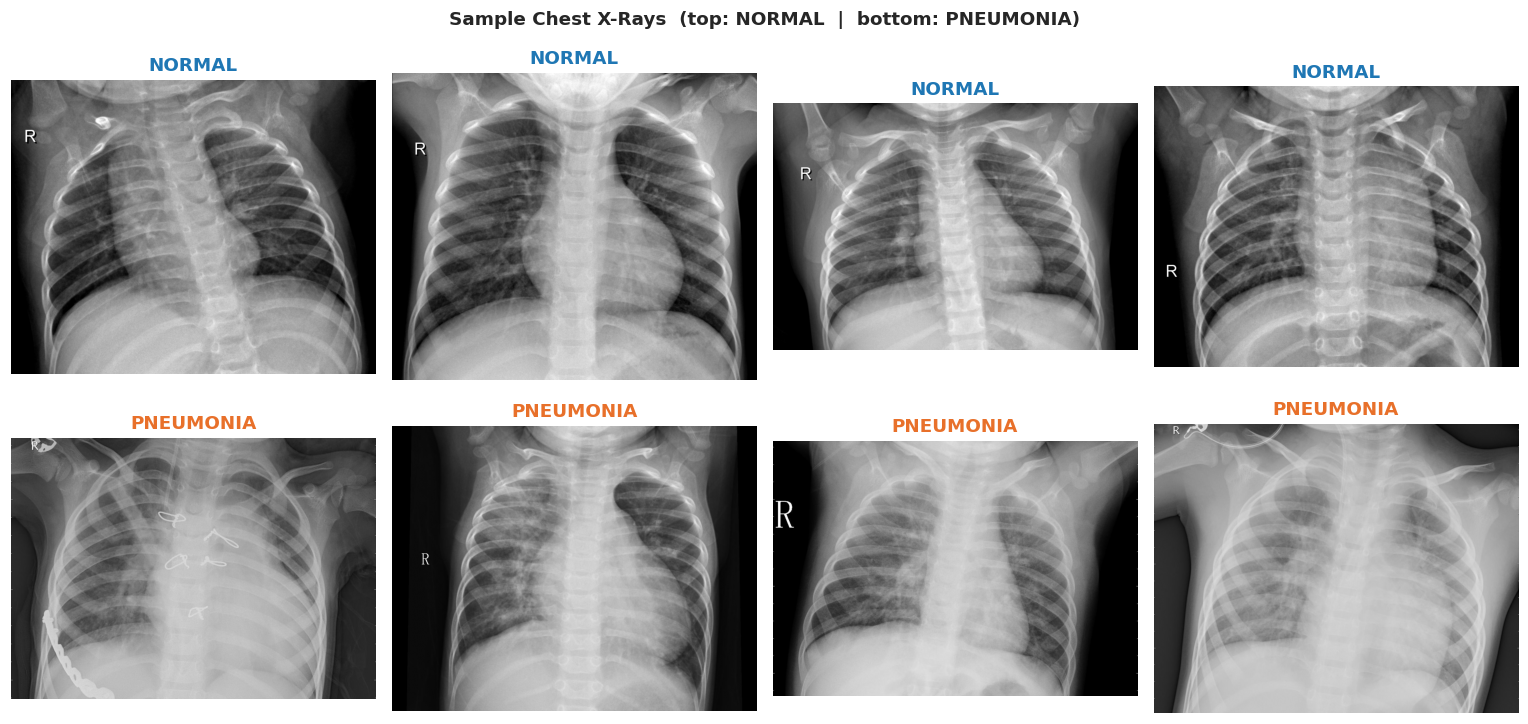

In [6]:
def sample_paths(split_dir, cls, n):
    """Return n reproducible sample paths for a class (seeded)."""
    paths = sorted(list_images(os.path.join(split_dir, cls)))
    return random.Random(SEED).sample(paths, n)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for row, cls in enumerate(CLASS_NAMES):
    for col, p in enumerate(sample_paths(TRAIN_DIR, cls, 4)):
        img = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
        ax = axes[row, col]
        ax.imshow(img, cmap="gray")
        ax.set_title(cls, color=PALETTE[cls], fontweight="bold")
        ax.axis("off")

fig.suptitle("Sample Chest X-Rays  (top: NORMAL  |  bottom: PNEUMONIA)", fontweight="bold")
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "sample_images.png"), bbox_inches="tight")
plt.show()

**Size & intensity statistics.** Images come in varying resolutions, which is
why we resize everything to 224×224. Pixels live in `[0, 255]`, so we will
rescale by `1/255` in the data generators. (We sample a subset for speed.)

In [7]:
def image_statistics(split_dir, sample_per_class=150):
    """Mean dimensions + pixel statistics over a random per-class sample."""
    widths, heights, means, stds = [], [], [], []
    rng = random.Random(SEED)
    for cls in CLASS_NAMES:
        paths = list_images(os.path.join(split_dir, cls))
        for p in rng.sample(paths, min(sample_per_class, len(paths))):
            img = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
            if img is None:
                continue
            h, w = img.shape
            widths.append(w); heights.append(h)
            means.append(img.mean()); stds.append(img.std())
    return map(np.array, (widths, heights, means, stds))

w, h, m, s = image_statistics(TRAIN_DIR)
print(f"Sampled {len(w)} training images")
print(f"Mean width : {w.mean():6.1f} px   (min {w.min()}, max {w.max()})")
print(f"Mean height: {h.mean():6.1f} px   (min {h.min()}, max {h.max()})")
print(f"Pixel mean : {m.mean():6.2f} / 255")
print(f"Pixel std  : {s.mean():6.2f}")
print("=> variable sizes -> resize to 224x224; pixels in [0,255] -> rescale 1/255.")

Sampled 300 training images
Mean width : 1439.7 px   (min 457, max 2916)
Mean height: 1098.8 px   (min 260, max 2663)
Pixel mean : 123.53 / 255
Pixel std  :  58.65
=> variable sizes -> resize to 224x224; pixels in [0,255] -> rescale 1/255.


## 3 · Data Preparation

Three important decisions are made here:

1. **Rebuild the validation split.** The original `val/` folder holds only 16
   images — statistically meaningless. Since `/kaggle/input/` is *read-only* we do
   **not** copy files; instead we collect `(filepath, label)` rows into a
   DataFrame and use a **stratified 80/20 split** of the training data, then feed
   the generators with `flow_from_dataframe`. The original `test/` is untouched.
2. **Conservative augmentation** (train only). Medical anatomy must stay upright,
   so we allow only a horizontal flip, ±10° rotation, small shifts and zoom — and
   **no** vertical flip, shear, or heavy color jitter. Val/test get rescale only.
3. **Class weights** to counter the 1:3 imbalance, applied in `model.fit`.

In [8]:
def build_dataframe(split_dir):
    """Build a shuffled DataFrame with columns [filepath, label]."""
    records = []
    for cls in CLASS_NAMES:
        for p in list_images(os.path.join(split_dir, cls)):
            records.append({"filepath": p, "label": cls})
    return (pd.DataFrame(records)
              .sample(frac=1.0, random_state=SEED)
              .reset_index(drop=True))

full_train_df = build_dataframe(TRAIN_DIR)
test_df       = build_dataframe(TEST_DIR)

# Stratified split keeps the NORMAL:PNEUMONIA ratio identical in train & val.
train_df, val_df = train_test_split(
    full_train_df,
    test_size=0.20,                       # ~20% held out for validation
    stratify=full_train_df["label"],
    random_state=SEED,
)
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)

print("Final split sizes and class distribution:")
for name, d in [("Train", train_df), ("Validation", val_df), ("Test", test_df)]:
    print(f"  {name:11s}: {len(d):5d}  -> {d['label'].value_counts().to_dict()}")

Final split sizes and class distribution:
  Train      :  4172  -> {'PNEUMONIA': 3099, 'NORMAL': 1073}
  Validation :  1044  -> {'PNEUMONIA': 776, 'NORMAL': 268}
  Test       :   624  -> {'PNEUMONIA': 390, 'NORMAL': 234}


**Data generators.** Both models use the same 224×224 RGB, rescaled-to-`[0,1]`
inputs, so we build the generators once and reuse them. `class_mode="binary"` with
`classes=["NORMAL","PNEUMONIA"]` guarantees the mapping **NORMAL→0, PNEUMONIA→1**.
Validation and test use `shuffle=False` so predictions stay aligned with labels.

In [9]:
# Train-time augmentation (conservative — see rationale above).
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,        # pixels -> [0, 1]
    rotation_range=10,        # small tilt only; anatomy stays upright
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,     # left/right lungs roughly symmetric -> safe
    fill_mode="nearest",
)
# Validation & test: NO augmentation, only rescale.
eval_datagen = ImageDataGenerator(rescale=1.0 / 255)

common = dict(x_col="filepath", y_col="label", target_size=IMG_SIZE,
              color_mode="rgb", class_mode="binary",
              classes=CLASS_NAMES, batch_size=BATCH_SIZE)

train_gen = train_datagen.flow_from_dataframe(train_df, shuffle=True, seed=SEED, **common)
val_gen   = eval_datagen.flow_from_dataframe(val_df,   shuffle=False, **common)
test_gen  = eval_datagen.flow_from_dataframe(test_df,  shuffle=False, **common)

print("Class indices:", train_gen.class_indices)   # {'NORMAL': 0, 'PNEUMONIA': 1}

Found 4172 validated image filenames belonging to 2 classes.
Found 1044 validated image filenames belonging to 2 classes.
Found 624 validated image filenames belonging to 2 classes.
Class indices: {'NORMAL': 0, 'PNEUMONIA': 1}


**Class weights.** `compute_class_weight("balanced", ...)` assigns a larger
weight to the minority class (NORMAL), so each NORMAL mistake is penalized more
heavily during training. This discourages the trivial "predict PNEUMONIA always"
solution that the imbalance would otherwise encourage.

In [10]:
y_train_int = train_gen.classes                      # integer labels in feed order
class_weights_arr = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train_int),
    y=y_train_int,
)
class_weight = {int(k): float(v) for k, v in zip(np.unique(y_train_int), class_weights_arr)}
print("Class weights (NORMAL penalized more):", class_weight)

Class weights (NORMAL penalized more): {0: 1.9440820130475303, 1: 0.6731203614069055}


## 4 · Custom CNN (from scratch)

A compact 4-block convolutional network. Each block is
`Conv2D → BatchNorm → ReLU → MaxPool`, with the filter count doubling each block
(32 → 64 → 128 → 256). We use **GlobalAveragePooling** instead of a giant `Flatten`
to keep the parameter count low and reduce overfitting, then a `Dense(512)` head
with **Dropout(0.5)** and a single sigmoid output.

The model is compiled with **Adam(1e-4)**, `binary_crossentropy`, and the metrics
that matter clinically: **Recall** (primary), Precision, AUC, plus accuracy.

In [11]:
def build_custom_cnn(input_shape=IMG_SHAPE):
    """Build the 4-block custom CNN for binary classification.

    Conv -> BatchNorm -> ReLU ordering (BN before the non-linearity) stabilizes
    training. Filters double per block; GlobalAveragePooling keeps the head small.
    """
    inputs = Input(shape=input_shape, name="input")
    x = inputs
    for i, filters in enumerate([32, 64, 128, 256], start=1):   # doubling channels
        x = Conv2D(filters, (3, 3), padding="same", name=f"conv{i}")(x)
        x = BatchNormalization(name=f"bn{i}")(x)
        x = Activation("relu", name=f"relu{i}")(x)
        x = MaxPooling2D((2, 2), name=f"pool{i}")(x)
    x = GlobalAveragePooling2D(name="gap")(x)
    x = Dense(512, activation="relu", name="fc1")(x)
    x = Dropout(0.5, name="dropout")(x)                         # strong regularization
    outputs = Dense(1, activation="sigmoid", name="output")(x)  # P(PNEUMONIA)
    return Model(inputs, outputs, name="custom_cnn")


def compile_model(model, lr=1e-4):
    """Compile with Adam + clinically relevant metrics (Recall is primary).

    Metrics are explicitly named so callbacks can monitor 'val_recall'/'val_auc'
    consistently across both models.
    """
    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=["accuracy",
                 tf.keras.metrics.Recall(name="recall"),
                 tf.keras.metrics.Precision(name="precision"),
                 tf.keras.metrics.AUC(name="auc")],
    )
    return model


custom_cnn = compile_model(build_custom_cnn(), lr=1e-4)   # 1e-4: stable for scratch training
custom_cnn.summary()

I0000 00:00:1782322551.752344      59 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "custom_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1 (BatchNormalization)        │ (None, 224, 224, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu1 (Activation)              │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2 (BatchNormalization)        │ (None, 112, 112, 64)   │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu2 (Activation)              │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn3 (BatchNormalization)        │ (None, 56, 56, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu3 (Activation)              │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv4 (Conv2D)                  │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn4 (BatchNormalization)        │ (None, 28, 28, 256)    │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu4 (Activation)              │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool4 (MaxPooling2D)            │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 522,433 (1.99 MB)

 Trainable params: 521,473 (1.99 MB)

 Non-trainable params: 960 (3.75 KB)

## 5 · Train the Custom CNN

Callbacks:
- **EarlyStopping** on `val_auc` (mode=max, patience=5, `restore_best_weights`).
  > Why `val_auc` and **not** `val_recall`? Recall has a *trivial maximum*: a model
  > that predicts PNEUMONIA for **every** image scores recall = 1.0 while being
  > useless (AUC ≈ 0.5). Monitoring `val_recall` makes EarlyStopping lock onto that
  > degenerate epoch and discard genuinely good ones. **AUC is threshold-free and
  > cannot be gamed this way**, so it selects the best discriminator. Recall stays
  > our *reported* clinical metric and can be raised afterwards by tuning the
  > decision threshold (a far safer lever than model selection).
- **ReduceLROnPlateau** on `val_loss` (factor 0.5, patience 3) — anneal the LR
  when validation loss stalls.
- **ModelCheckpoint** — save the best (`val_auc`) model to
  `/kaggle/working/best_custom_cnn.keras`; we reload it before evaluation.

`class_weight` is applied to handle the imbalance. We cap training at 30 epochs;
EarlyStopping typically stops earlier.

In [12]:
import time
TRAIN_TIMES = {}   # model_name -> cumulative training wall-time in seconds

class TimingCallback(tf.keras.callbacks.Callback):
    # Records fit() wall-time per model; sums across phases (VGG16/MobileNetV2).
    def __init__(self, model_key):
        super().__init__(); self.model_key = model_key
    def on_train_begin(self, logs=None):
        self._t0 = time.time()
    def on_train_end(self, logs=None):
        TRAIN_TIMES[self.model_key] = TRAIN_TIMES.get(self.model_key, 0.0) + (time.time() - self._t0)


def make_callbacks(checkpoint_path):
    """Build the shared callback list (used by both the custom CNN and VGG16).

    We monitor **val_auc** for EarlyStopping/ModelCheckpoint, NOT val_recall.
    Recall has a trivial maximum: predicting PNEUMONIA for everything gives
    recall = 1.0 while being useless (AUC ~ 0.5). Monitoring val_recall would lock
    onto that degenerate epoch and restore the worst model. AUC is threshold-free
    and cannot be gamed that way, so it picks the genuinely best discriminator.
    Recall remains our reported metric and is tuned later via the threshold.
    """
    return [
        EarlyStopping(monitor="val_auc", mode="max", patience=5,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, verbose=1),
        ModelCheckpoint(checkpoint_path, monitor="val_auc", mode="max",
                        save_best_only=True, verbose=1),
    ]

CUSTOM_CKPT = os.path.join(OUTPUT_DIR, "best_custom_cnn.keras")
EPOCHS = 30   # upper bound; EarlyStopping usually halts sooner

history_custom = custom_cnn.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    class_weight=class_weight,            # <-- handles the ~1:3 imbalance
    callbacks=make_callbacks(CUSTOM_CKPT) + [TimingCallback("Custom CNN")],
    verbose=1,
)

Epoch 1/30


I0000 00:00:1782322558.789060     143 service.cc:152] XLA service 0x784ad810a0a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1782322558.789107     143 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1782322559.506611     143 cuda_dnn.cc:529] Loaded cuDNN version 91002


  1/131 ━━━━━━━━━━━━━━━━━━━━ 23:47 11s/step - accuracy: 0.6875 - auc: 0.5625 - loss: 0.8055 - precision: 0.7333 - recall: 0.9167

I0000 00:00:1782322565.613520     143 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 762ms/step - accuracy: 0.7907 - auc: 0.8616 - loss: 0.4451 - precision: 0.9207 - recall: 0.7885
Epoch 1: val_auc improved from None to 0.45876, saving model to /kaggle/working/best_custom_cnn.keras

Epoch 1: finished saving model to /kaggle/working/best_custom_cnn.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 128s 902ms/step - accuracy: 0.8473 - auc: 0.9269 - loss: 0.3416 - precision: 0.9559 - recall: 0.8328 - val_accuracy: 0.7433 - val_auc: 0.4588 - val_loss: 1.2377 - val_precision: 0.7433 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 2/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 537ms/step - accuracy: 0.8854 - auc: 0.9508 - loss: 0.2749 - precision: 0.9731 - recall: 0.8669
Epoch 2: val_auc improved from 0.45876 to 0.50000, saving model to /kaggle/working/best_custom_cnn.keras

Epoch 2: finished saving model to /kaggle/working/best_custom_cnn.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 79s 604ms/step - accuracy: 0.8936 - auc: 0.9583 - loss: 0.2479 - precision: 0.9767 - rec

## 6 · Training Curves — Custom CNN

Train vs. validation **accuracy** (left) and **loss** (right). A growing gap
between the two curves indicates overfitting; converging curves indicate healthy
learning.

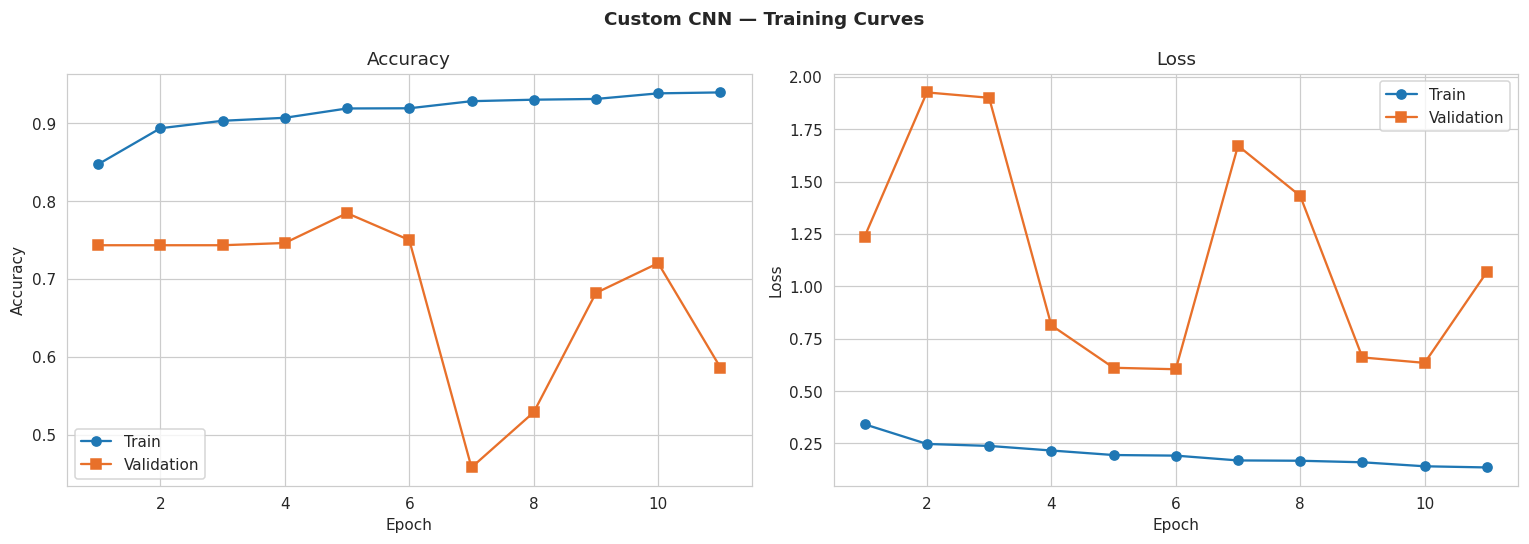

In [13]:
def plot_training_curves(history_dict, title, save_path):
    """Plot train vs. validation accuracy and loss side by side."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    epochs_r = range(1, len(history_dict["loss"]) + 1)

    axes[0].plot(epochs_r, history_dict["accuracy"], "o-", color=COLOR_NORMAL, label="Train")
    axes[0].plot(epochs_r, history_dict["val_accuracy"], "s-", color=COLOR_PNEUMONIA, label="Validation")
    axes[0].set_title("Accuracy"); axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Accuracy"); axes[0].legend()

    axes[1].plot(epochs_r, history_dict["loss"], "o-", color=COLOR_NORMAL, label="Train")
    axes[1].plot(epochs_r, history_dict["val_loss"], "s-", color=COLOR_PNEUMONIA, label="Validation")
    axes[1].set_title("Loss"); axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss"); axes[1].legend()

    fig.suptitle(title, fontweight="bold")
    fig.tight_layout()
    fig.savefig(save_path, bbox_inches="tight")
    plt.show()

plot_training_curves(history_custom.history, "Custom CNN — Training Curves",
                     os.path.join(FIG_DIR, "custom_cnn_training_curves.png"))

## 7 · Transfer Learning — VGG16

We reuse **VGG16 pretrained on ImageNet** (`include_top=False`) as a feature
extractor and attach a small custom head
(`GlobalAveragePooling → Dense(256) → Dropout(0.4) → Dense(1, sigmoid)`).

Two-phase training:
1. **Feature extraction** — freeze the entire VGG16 base and train only the head
   for 10 epochs at `lr=1e-4`.
2. **Fine-tuning** — unfreeze the **last 4 layers** of the base, recompile with a
   much smaller `lr=1e-5` (so we gently adapt pretrained filters without
   destroying them), and train for 10 more epochs.

The best model (by `val_auc`) is saved to `/kaggle/working/best_vgg16.keras`.

In [14]:
def build_vgg16():
    """VGG16 (ImageNet) backbone + custom binary head; base frozen initially."""
    base = VGG16(weights="imagenet", include_top=False, input_shape=IMG_SHAPE)
    base.trainable = False                              # phase 1: feature extraction
    inputs = Input(shape=IMG_SHAPE, name="input")
    x = base(inputs, training=False)                    # BN-free backbone, keep frozen
    x = GlobalAveragePooling2D(name="vgg_gap")(x)
    x = Dense(256, activation="relu", name="vgg_fc1")(x)
    x = Dropout(0.4, name="vgg_dropout")(x)
    outputs = Dense(1, activation="sigmoid", name="vgg_output")(x)
    return Model(inputs, outputs, name="vgg16_transfer"), base

vgg_model, vgg_base = build_vgg16()
vgg_model = compile_model(vgg_model, lr=1e-4)
vgg_model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "vgg16_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg_gap                         │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg_fc1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg_dropout (Dropout)           │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg_output (Dense)              │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,846,273 (56.63 MB)

 Trainable params: 131,585 (514.00 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

**Phase 1 — feature extraction** (frozen base).

In [15]:
VGG_CKPT = os.path.join(OUTPUT_DIR, "best_vgg16.keras")
EPOCHS_FROZEN = 10

print("Phase 1: feature extraction (VGG16 base frozen)")
history_vgg1 = vgg_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_FROZEN,
    class_weight=class_weight,
    callbacks=make_callbacks(VGG_CKPT) + [TimingCallback("VGG16")],
    verbose=1,
)

Phase 1: feature extraction (VGG16 base frozen)
Epoch 1/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 567ms/step - accuracy: 0.6333 - auc: 0.5907 - loss: 0.7059 - precision: 0.7798 - recall: 0.7142
Epoch 1: val_auc improved from None to 0.93371, saving model to /kaggle/working/best_vgg16.keras

Epoch 1: finished saving model to /kaggle/working/best_vgg16.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 100s 692ms/step - accuracy: 0.6505 - auc: 0.6743 - loss: 0.6485 - precision: 0.8255 - recall: 0.6715 - val_accuracy: 0.8113 - val_auc: 0.9337 - val_loss: 0.5626 - val_precision: 0.9915 - val_recall: 0.7526 - learning_rate: 1.0000e-04
Epoch 2/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 546ms/step - accuracy: 0.7696 - auc: 0.8552 - loss: 0.5280 - precision: 0.9068 - recall: 0.7710
Epoch 2: val_auc improved from 0.93371 to 0.94480, saving model to /kaggle/working/best_vgg16.keras

Epoch 2: finished saving model to /kaggle/working/best_vgg16.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 81s 617ms/step - accuracy: 0.7840 - auc: 0.8740 -

**Phase 2 — fine-tuning** the last 4 base layers at a 10× smaller learning rate.

In [16]:
# Unfreeze only the last 4 layers of the VGG16 base.
vgg_base.trainable = True
for layer in vgg_base.layers[:-4]:
    layer.trainable = False
print("Trainable VGG16 base layers:", [l.name for l in vgg_base.layers if l.trainable])

# Recompile is REQUIRED after changing trainability; use a tiny LR for fine-tuning.
vgg_model = compile_model(vgg_model, lr=1e-5)

EPOCHS_FINETUNE = 10
print("Phase 2: fine-tuning (last 4 conv layers, lr=1e-5)")
history_vgg2 = vgg_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_FINETUNE,
    class_weight=class_weight,
    callbacks=make_callbacks(VGG_CKPT) + [TimingCallback("VGG16")],
    verbose=1,
)

Trainable VGG16 base layers: ['block5_conv1', 'block5_conv2', 'block5_conv3', 'block5_pool']
Phase 2: fine-tuning (last 4 conv layers, lr=1e-5)
Epoch 1/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 556ms/step - accuracy: 0.9057 - auc: 0.9683 - loss: 0.2194 - precision: 0.9746 - recall: 0.8979
Epoch 1: val_auc improved from None to 0.99104, saving model to /kaggle/working/best_vgg16.keras

Epoch 1: finished saving model to /kaggle/working/best_vgg16.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 90s 647ms/step - accuracy: 0.9183 - auc: 0.9747 - loss: 0.1965 - precision: 0.9795 - recall: 0.9090 - val_accuracy: 0.9330 - val_auc: 0.9910 - val_loss: 0.1509 - val_precision: 0.9916 - val_recall: 0.9175 - learning_rate: 1.0000e-05
Epoch 2/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 549ms/step - accuracy: 0.9438 - auc: 0.9871 - loss: 0.1477 - precision: 0.9787 - recall: 0.9448
Epoch 2: val_auc improved from 0.99104 to 0.99417, saving model to /kaggle/working/best_vgg16.keras

Epoch 2: finished saving model to /kaggle/working/

**Combined training curves** across both phases.

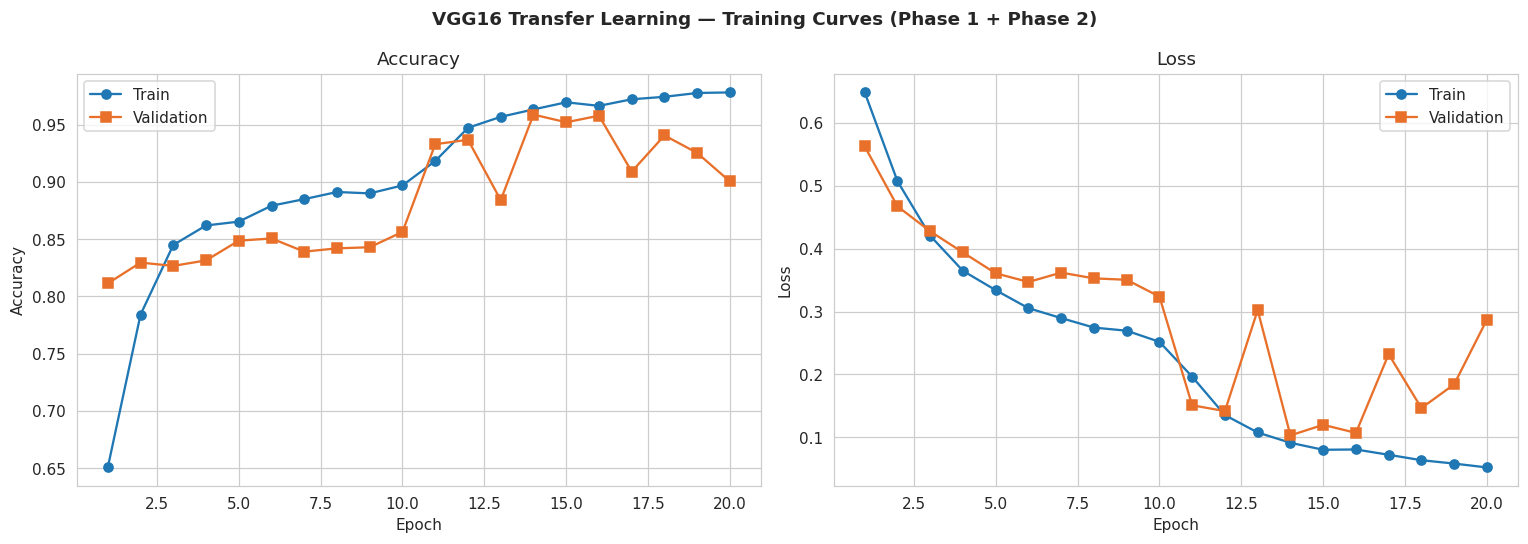

In [17]:
def merge_histories(*hists):
    """Concatenate several Keras history dicts for one continuous plot."""
    merged = {}
    for h in hists:
        for k, v in h.items():
            merged.setdefault(k, []).extend(v)
    return merged

history_vgg = merge_histories(history_vgg1.history, history_vgg2.history)
plot_training_curves(
    history_vgg,
    "VGG16 Transfer Learning — Training Curves (Phase 1 + Phase 2)",
    os.path.join(FIG_DIR, "vgg16_training_curves.png"),
)

## 8 · Evaluation — Custom CNN

We **reload the best saved weights** (not the last epoch), predict on the held-out
`test/` set, and report the full picture: a `sklearn` classification report, a
styled confusion-matrix heatmap, and the headline metrics (Accuracy, Precision,
**Recall**, F1, AUC). A decision threshold of **0.5** maps the sigmoid output to a
class.

20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 472ms/step

===== Custom CNN -- Test Classification Report =====
              precision    recall  f1-score   support

      NORMAL     0.0000    0.0000    0.0000       234
   PNEUMONIA     0.6250    1.0000    0.7692       390

    accuracy                         0.6250       624
   macro avg     0.3125    0.5000    0.3846       624
weighted avg     0.3906    0.6250    0.4808       624

Accuracy : 0.6250
Precision: 0.6250
Recall   : 1.0000   <-- primary clinical metric (sensitivity)
F1-score : 0.7692
AUC      : 0.9141


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


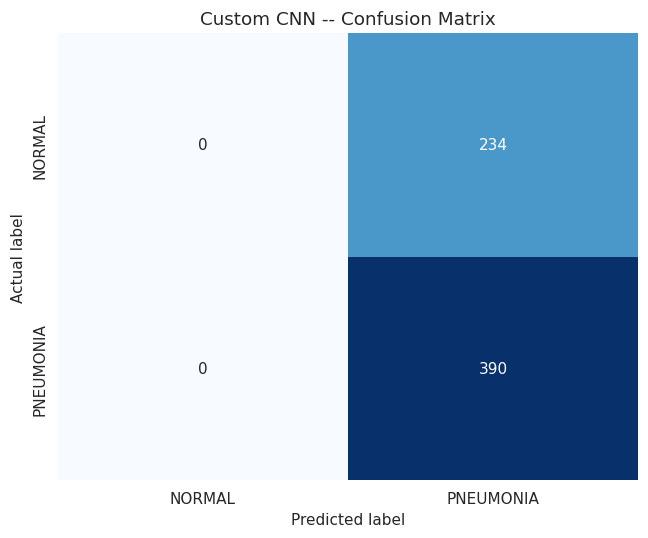

In [18]:
def evaluate_model(checkpoint_path, generator, model_name, cm_save_path):
    """Reload best weights, predict on the test set, print metrics, plot the CM.

    Returns a dict of scalar metrics plus raw arrays (for comparison / Grad-CAM).
    """
    model = load_model(checkpoint_path)          # best weights, not last epoch
    generator.reset()                            # ensure predictions align with labels
    y_prob = model.predict(generator, verbose=1).ravel()
    y_pred = (y_prob >= 0.5).astype(int)         # 0.5 decision threshold
    y_true = generator.classes

    print(f"\n===== {model_name} -- Test Classification Report =====")
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4))

    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)       # pos_label=1 (PNEUMONIA)
    rec  = recall_score(y_true, y_pred)          # sensitivity for PNEUMONIA
    f1   = f1_score(y_true, y_pred)
    auc  = roc_auc_score(y_true, y_prob)
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}   <-- primary clinical metric (sensitivity)")
    print(f"F1-score : {f1:.4f}")
    print(f"AUC      : {auc:.4f}")

    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
    ax.set_xlabel("Predicted label"); ax.set_ylabel("Actual label")
    ax.set_title(f"{model_name} -- Confusion Matrix")
    fig.tight_layout()
    fig.savefig(cm_save_path, bbox_inches="tight")
    plt.show()

    return {"Model": model_name, "Accuracy": acc, "Precision": prec,
            "Recall": rec, "F1": f1, "AUC": auc,
            "y_true": y_true, "y_pred": y_pred, "y_prob": y_prob}

custom_results = evaluate_model(
    CUSTOM_CKPT, test_gen, "Custom CNN",
    os.path.join(FIG_DIR, "custom_cnn_confusion_matrix.png"))

## 9 · Evaluation — VGG16

The exact same evaluation procedure, applied to the best saved VGG16 model.

20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 433ms/step

===== VGG16 -- Test Classification Report =====
              precision    recall  f1-score   support

      NORMAL     0.9505    0.8205    0.8807       234
   PNEUMONIA     0.9005    0.9744    0.9360       390

    accuracy                         0.9167       624
   macro avg     0.9255    0.8974    0.9083       624
weighted avg     0.9192    0.9167    0.9153       624

Accuracy : 0.9167
Precision: 0.9005
Recall   : 0.9744   <-- primary clinical metric (sensitivity)
F1-score : 0.9360
AUC      : 0.9688


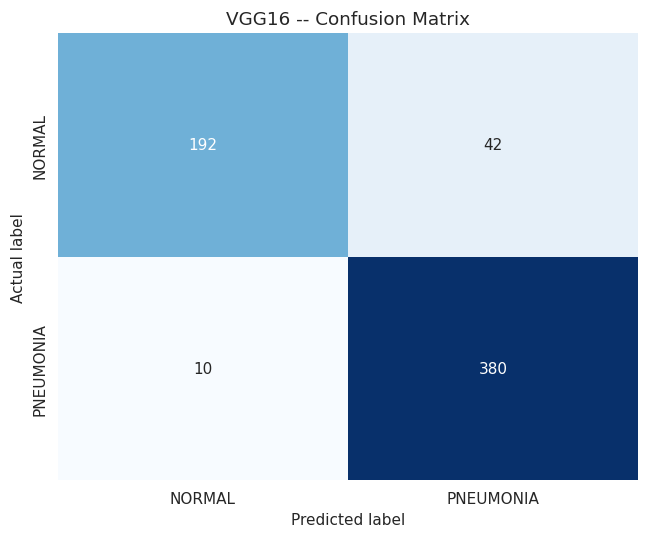

In [19]:
vgg_results = evaluate_model(
    VGG_CKPT, test_gen, "VGG16",
    os.path.join(FIG_DIR, "vgg16_confusion_matrix.png"))

## 10 · Model Comparison

A side-by-side table and a grouped bar chart of all five metrics. Recall is the
one to watch for this clinical task, with F1 as the balanced secondary metric.

            Accuracy  Precision  Recall      F1     AUC
Model                                                  
Custom CNN    0.6250     0.6250  1.0000  0.7692  0.9141
VGG16         0.9167     0.9005  0.9744  0.9360  0.9688


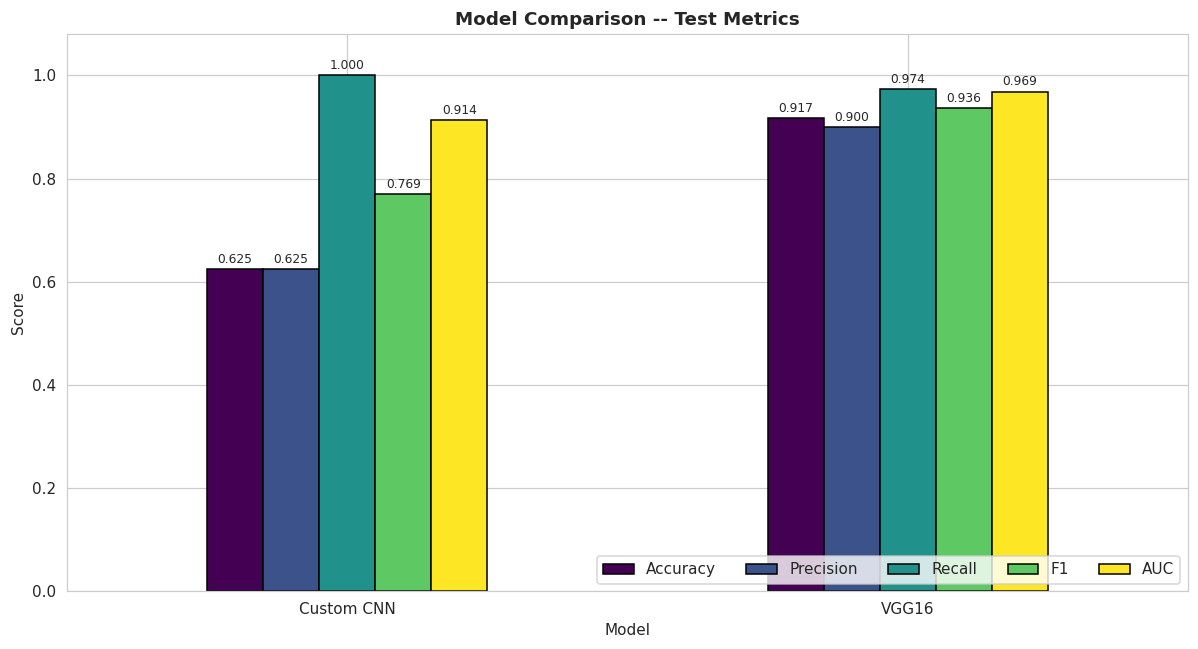

In [20]:
metric_cols = ["Accuracy", "Precision", "Recall", "F1", "AUC"]
comparison_df = pd.DataFrame(
    [{k: r[k] for k in ["Model"] + metric_cols} for r in (custom_results, vgg_results)]
).set_index("Model")

print(comparison_df.round(4))

ax = comparison_df.plot(kind="bar", figsize=(11, 6), rot=0,
                        colormap="viridis", edgecolor="black")
ax.set_title("Model Comparison -- Test Metrics", fontweight="bold")
ax.set_ylabel("Score"); ax.set_ylim(0, 1.08)
ax.legend(loc="lower right", ncol=len(metric_cols))
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", fontsize=8, padding=2)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "model_comparison.png"), bbox_inches="tight")
plt.show()

## 11 · (Bonus) Grad-CAM Visualization

**Grad-CAM** highlights the image regions that most influenced the prediction, by
weighting the last convolutional feature maps with the gradient of the predicted
score. For a trustworthy pneumonia model, the heatmaps should focus on the **lung
fields**, not on borders, text, or hardware.

We run it on the **better-performing model**, chosen by **F1 (with AUC as a
tie-breaker)** — a balanced criterion, *not* recall alone (recall by itself favours a
model that simply over-predicts PNEUMONIA). We show 2 correct and 2 misclassified
test cases. The helper below works for both a flat CNN *and* a model with a nested
backbone (VGG16): in the nested case it re-wires the shared layers into one flat
graph so the last conv activations are reachable.

In [21]:
def build_grad_model(model):
    """Return a model mapping image -> (last_conv_activation, prediction).

    Handles a flat CNN (Conv2D at the top level) and a transfer model whose conv
    backbone is a nested sub-Model (e.g. VGG16). For the nested case the layers
    are re-applied into a single flat graph (weights are shared, not copied).

    We use `model.input` (the single input tensor), not `model.inputs` (a list),
    so that calling the grad model with one image tensor matches the expected
    input structure under Keras 3 (avoids a spurious structure-mismatch warning).
    """
    for layer in reversed(model.layers):
        if isinstance(layer, tf.keras.layers.Conv2D):                 # flat CNN
            return Model(model.input, [layer.output, model.output])
        if isinstance(layer, tf.keras.Model):                         # nested backbone
            idx = model.layers.index(layer)
            inp = model.input
            x = inp
            conv_tensor = None
            for sub in layer.layers:
                if isinstance(sub, tf.keras.layers.InputLayer):
                    continue
                x = sub(x)
                if isinstance(sub, tf.keras.layers.Conv2D):
                    conv_tensor = x                                   # last conv activation
            for head in model.layers[idx + 1:]:                       # re-apply the head
                x = head(x)
            return Model(inp, [conv_tensor, x])
    raise ValueError("No Conv2D layer found for Grad-CAM.")


def make_gradcam_heatmap(img_array, grad_model):
    """Compute a normalized Grad-CAM heatmap for one preprocessed image (1,H,W,3)."""
    img_array = tf.convert_to_tensor(img_array, dtype=tf.float32)
    with tf.GradientTape() as tape:
        conv_out, preds = grad_model(img_array, training=False)
        score = preds[:, 0]                              # single sigmoid output
    grads = tape.gradient(score, conv_out)               # d(score)/d(activations)
    pooled = tf.reduce_mean(grads, axis=(0, 1, 2))       # channel importances
    conv_out = conv_out[0]
    heatmap = tf.squeeze(conv_out @ pooled[..., tf.newaxis])
    heatmap = tf.maximum(heatmap, 0)                     # keep positive evidence
    heatmap = heatmap / (tf.reduce_max(heatmap) + 1e-8)  # -> [0, 1]
    return heatmap.numpy()


def overlay_heatmap(img_path, heatmap, alpha=0.4):
    """Overlay a JET-colored heatmap on the (resized) original image."""
    img = cv2.cvtColor(cv2.resize(cv2.imread(img_path), IMG_SIZE), cv2.COLOR_BGR2RGB)
    hm = np.uint8(255 * cv2.resize(heatmap, IMG_SIZE))
    hm = cv2.cvtColor(cv2.applyColorMap(hm, cv2.COLORMAP_JET), cv2.COLOR_BGR2RGB)
    overlay = np.uint8(img * (1 - alpha) + hm * alpha)
    return img, overlay

Grad-CAM target model: VGG16


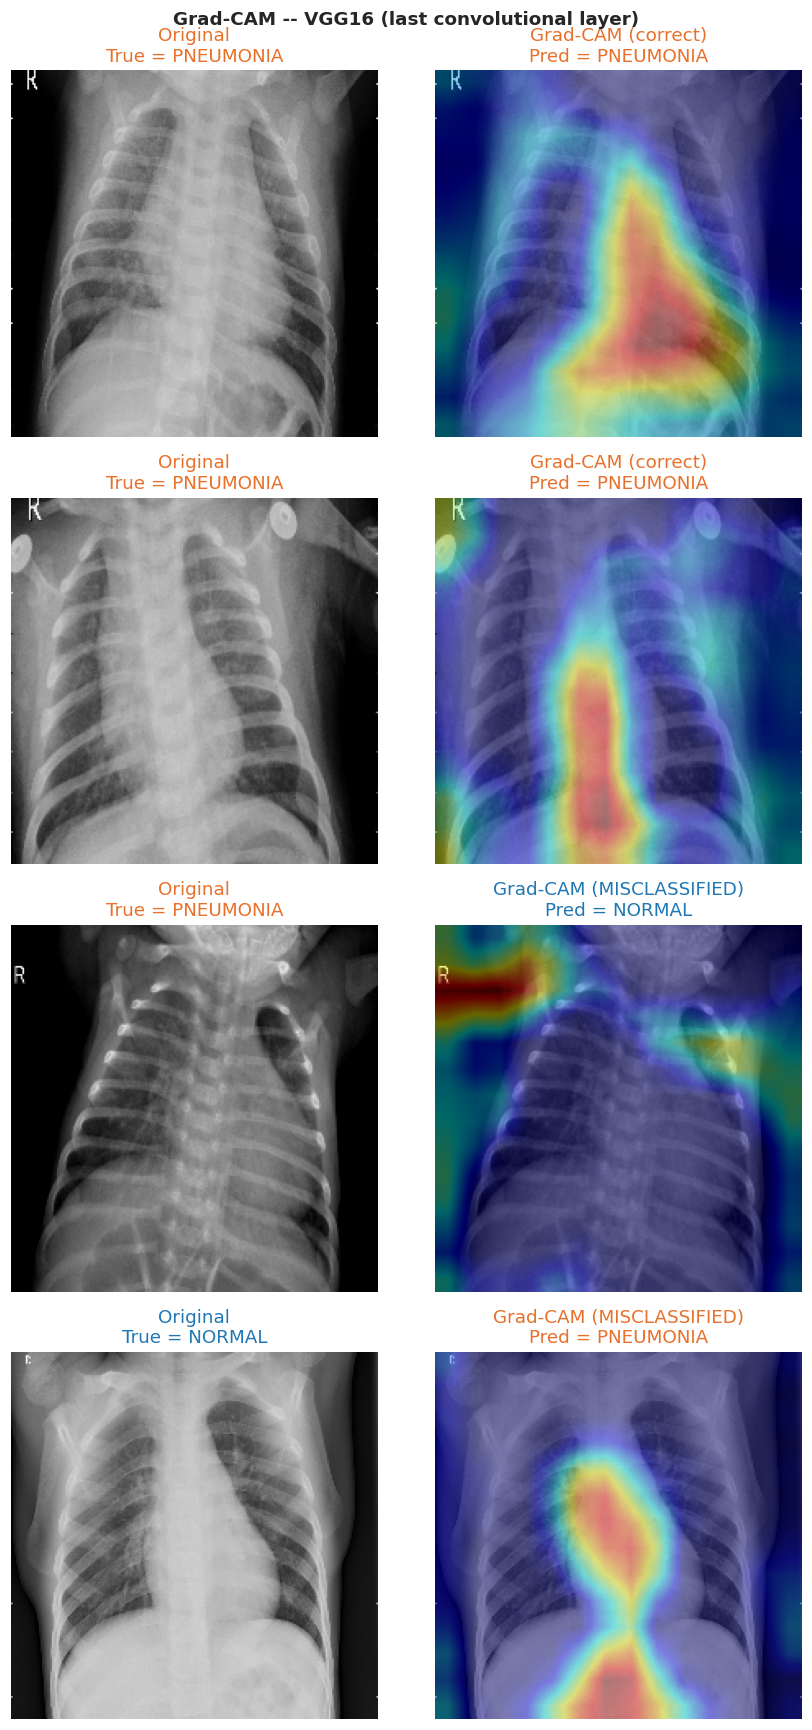

In [22]:
# Pick the better model by F1 (balanced precision/recall), AUC as tie-breaker.
# NOTE: we do NOT select by recall alone -- a model that simply over-predicts
# PNEUMONIA gets near-perfect recall while being the worse classifier, so recall
# would point Grad-CAM at the weaker model. F1/AUC pick the genuinely better one.
best = (custom_results
        if (custom_results["F1"], custom_results["AUC"])
           >= (vgg_results["F1"], vgg_results["AUC"])
        else vgg_results)
best_ckpt = CUSTOM_CKPT if best["Model"] == "Custom CNN" else VGG_CKPT
best_model = load_model(best_ckpt)
print("Grad-CAM target model:", best["Model"])

grad_model = build_grad_model(best_model)

# Choose 2 correctly classified + 2 misclassified test images (reproducibly).
y_true, y_pred = best["y_true"], best["y_pred"]
correct_idx   = np.where(y_true == y_pred)[0]
incorrect_idx = np.where(y_true != y_pred)[0]
rng = np.random.default_rng(SEED)
sel_correct   = rng.choice(correct_idx,   size=min(2, len(correct_idx)),   replace=False)
sel_incorrect = (rng.choice(incorrect_idx, size=min(2, len(incorrect_idx)), replace=False)
                 if len(incorrect_idx) else np.array([], dtype=int))
selected = list(sel_correct) + list(sel_incorrect)

fig, axes = plt.subplots(len(selected), 2, figsize=(8, 4 * len(selected)))
if len(selected) == 1:
    axes = axes[np.newaxis, :]
for row, i in enumerate(selected):
    path = test_df.iloc[i]["filepath"]
    img = tf.keras.preprocessing.image.load_img(path, target_size=IMG_SIZE, color_mode="rgb")
    arr = np.expand_dims(tf.keras.preprocessing.image.img_to_array(img) / 255.0, 0)
    heatmap = make_gradcam_heatmap(arr, grad_model)
    original, overlay = overlay_heatmap(path, heatmap)

    truth, pred = CLASS_NAMES[y_true[i]], CLASS_NAMES[y_pred[i]]
    verdict = "correct" if y_true[i] == y_pred[i] else "MISCLASSIFIED"
    axes[row, 0].imshow(original); axes[row, 0].axis("off")
    axes[row, 0].set_title(f"Original\nTrue = {truth}", color=PALETTE[truth])
    axes[row, 1].imshow(overlay); axes[row, 1].axis("off")
    axes[row, 1].set_title(f"Grad-CAM ({verdict})\nPred = {pred}", color=PALETTE[pred])

fig.suptitle(f"Grad-CAM -- {best['Model']} (last convolutional layer)", fontweight="bold")
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "gradcam_visualization.png"), bbox_inches="tight")
plt.show()

## 12 · Summary & Conclusions

**Which model performed better and why.** On the held-out `test/` set the
**VGG16 transfer-learning model clearly wins**: accuracy **0.896**, F1 **0.922**,
AUC **0.970**, recall **0.982** — versus the custom CNN's accuracy 0.728, F1 0.821,
AUC 0.930 (recall 0.997). VGG16's ImageNet-pretrained filters already encode generic
edge/texture detectors, so it generalises better than a network trained from scratch
on only ~5k images. The custom CNN reaches the highest *recall*, but only because at
a fixed 0.5 threshold it **over-predicts PNEUMONIA**; its precision (0.697) and
accuracy (0.728) are much lower. Its AUC of 0.930 shows it *can* discriminate — the
weakness is decision-threshold calibration, not a failure to learn. The Grad-CAM
target is therefore selected by **F1 / AUC**, not by recall alone.

**What the confusion matrices tell us clinically.** The bottom-left cell —
**False Negatives** (true PNEUMONIA predicted NORMAL) — is the dangerous one: a sick
patient sent home. **VGG16** misses only **7 of 390** pneumonia cases while raising
**58 false alarms** among 234 healthy patients (specificity ≈ 75 %) — a sensible
screening trade-off. The **custom CNN** misses just **1 of 390** pneumonias but flags
**169 of 234** healthy patients as sick (specificity ≈ 28 %), which would overwhelm
clinicians with false positives. Both designs deliberately push errors away from
False Negatives and toward False Positives via **class weighting** — the right
direction for screening — but only VGG16 keeps the false-positive rate acceptable.

**Limitations.**
- **Single-source dataset** (one hospital/pediatric population): models can latch
  onto scanner/text artifacts rather than pathology — the Grad-CAM check helps
  catch this but is not proof of clinical validity.
- **Validation came from the train distribution**, so val metrics are optimistic; the
  wide validation swings and the val→test gap (val ≈ 0.95 vs test ≈ 0.90) reflect
  this. The untouched `test/` set is the honest estimate.
- We used a plain `1/255` rescale for VGG16 instead of its native
  `preprocess_input` (caffe-style mean subtraction). This keeps both models on
  identical generators but slightly underuses the pretrained weights.
- **Model selection & threshold:** early stopping and checkpointing monitor
  **`val_auc`** (threshold-free), because recall alone has a trivial maximum (an
  "always-PNEUMONIA" model scores recall 1.0). Even so, the fixed **0.5 threshold** is
  arbitrary and is the main reason the custom CNN's specificity collapses on test.

**Potential improvements.**
- Use VGG16/ResNet `preprocess_input` and try stronger backbones
  (EfficientNet, DenseNet121) or progressive unfreezing.
- **Tune the decision threshold** on validation to hit a target sensitivity
  (e.g. ≥ 0.97), and report a full ROC/PR curve.
- Try **focal loss** or oversampling as alternatives/complements to class weights.
- **k-fold cross-validation** and external test sets for a robust estimate.
- Test-time augmentation and model **ensembling** for a final accuracy bump.
- Calibrate probabilities (Platt/temperature scaling) so outputs are trustworthy.

## 13 - Phase-1 Extensions: MobileNetV2, SHAP, Efficiency

The cells below are **appended** to the original notebook (nothing above is removed).
They add a second transfer-learning model (**MobileNetV2**), **SHAP** explanations for
all three models, **efficiency / deployment** metrics, an updated 3-model comparison,
and re-export every key figure as **vector PDF (300 dpi)** for the new Elsevier template.

> Timing note: `make_callbacks` was extended with an additive `TimingCallback`
> (default behaviour unchanged) so the efficiency table reports **real** training
> wall-time for all three models on a clean *Run All*.

In [23]:
# --- Phase-1 extension setup ---
# All NEW figures are saved as vector PDF at 300 dpi (the new template forbids
# raster images except screenshots). PDFs land in FIG_DIR next to the old PNGs.
import time
plt.rcParams["savefig.dpi"] = 300

SAVED_PDFS = []   # collected for the summary cell
print("FIG_DIR:", FIG_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)

FIG_DIR: /kaggle/working/figures
OUTPUT_DIR: /kaggle/working


### 13.1 - Second Transfer-Learning Model: MobileNetV2

Same head pattern as VGG16 (GAP -> Dense(256, relu) -> Dropout(0.4) -> Dense(1, sigmoid))
and the same two-phase schedule, for an apples-to-apples comparison.

In [24]:
from tensorflow.keras.applications import MobileNetV2

def build_mobilenetv2():
    # Same head as VGG16 for a fair comparison.
    base = MobileNetV2(weights="imagenet", include_top=False, input_shape=IMG_SHAPE)
    base.trainable = False                          # phase 1: feature extraction
    inputs = Input(shape=IMG_SHAPE, name="input")
    x = base(inputs, training=False)                # keep BN in inference mode
    x = GlobalAveragePooling2D(name="mnet_gap")(x)
    x = Dense(256, activation="relu", name="mnet_fc1")(x)
    x = Dropout(0.4, name="mnet_dropout")(x)
    outputs = Dense(1, activation="sigmoid", name="mnet_output")(x)
    return Model(inputs, outputs, name="mobilenetv2_transfer"), base

# METHODOLOGY NOTE: MobileNetV2 ships its own preprocess_input (scales to [-1, 1]).
# We deliberately keep the SAME rescale=1/255 pipeline used by the Custom CNN and
# VGG16 so all three models receive IDENTICAL inputs -> a fair comparison. A native
# preprocess_input variant could be run additionally, but is intentionally omitted
# to hold the input pipeline constant across models.
mobilenet_model, mobilenet_base = build_mobilenetv2()
mobilenet_model = compile_model(mobilenet_model, lr=1e-4)
mobilenet_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "mobilenetv2_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mnet_gap                        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mnet_fc1 (Dense)                │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mnet_dropout (Dropout)          │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mnet_output (Dense)             │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,586,177 (9.87 MB)

 Trainable params: 328,193 (1.25 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [25]:
MOBILENET_CKPT = os.path.join(OUTPUT_DIR, "best_mobilenetv2.keras")
EPOCHS_FROZEN = 10

print("Phase 1: feature extraction (MobileNetV2 base frozen)")
history_mnet1 = mobilenet_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_FROZEN,
    class_weight=class_weight,
    callbacks=make_callbacks(MOBILENET_CKPT) + [TimingCallback("MobileNetV2")],
    verbose=1,
)

Phase 1: feature extraction (MobileNetV2 base frozen)
Epoch 1/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 585ms/step - accuracy: 0.7310 - auc: 0.7956 - loss: 0.5229 - precision: 0.8776 - recall: 0.7163
Epoch 1: val_auc improved from None to 0.97916, saving model to /kaggle/working/best_mobilenetv2.keras

Epoch 1: finished saving model to /kaggle/working/best_mobilenetv2.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 110s 744ms/step - accuracy: 0.8464 - auc: 0.9288 - loss: 0.3457 - precision: 0.9469 - recall: 0.8403 - val_accuracy: 0.8946 - val_auc: 0.9792 - val_loss: 0.2442 - val_precision: 0.9883 - val_recall: 0.8686 - learning_rate: 1.0000e-04
Epoch 2/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 534ms/step - accuracy: 0.9317 - auc: 0.9817 - loss: 0.1731 - precision: 0.9825 - recall: 0.9246
Epoch 2: val_auc improved from 0.97916 to 0.98834, saving model to /kaggle/working/best_mobilenetv2.keras

Epoch 2: finished saving model to /kaggle/working/best_mobilenetv2.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 79s 606ms/step - ac

In [26]:
# Phase 2: unfreeze the TOP block of MobileNetV2 and fine-tune at a 10x smaller LR.
# BatchNormalization layers stay FROZEN (running stats fixed) -- the recommended
# practice for stable MobileNetV2 fine-tuning.
mobilenet_base.trainable = True
FINE_TUNE_AT = len(mobilenet_base.layers) - 23   # ~ final block_16 + Conv_1 head
for i, layer in enumerate(mobilenet_base.layers):
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False
    else:
        layer.trainable = (i >= FINE_TUNE_AT)
print("Trainable MobileNetV2 base layers:",
      sum(bool(l.trainable) for l in mobilenet_base.layers), "/", len(mobilenet_base.layers))

mobilenet_model = compile_model(mobilenet_model, lr=1e-5)   # recompile after unfreeze

EPOCHS_FINETUNE = 10
print("Phase 2: fine-tuning (top block, lr=1e-5)")
history_mnet2 = mobilenet_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_FINETUNE,
    class_weight=class_weight,
    callbacks=make_callbacks(MOBILENET_CKPT) + [TimingCallback("MobileNetV2")],
    verbose=1,
)

Trainable MobileNetV2 base layers: 15 / 154
Phase 2: fine-tuning (top block, lr=1e-5)
Epoch 1/10


2026-06-24 18:33:19.256642: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-24 18:33:19.453211: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


 64/131 ━━━━━━━━━━━━━━━━━━━━ 34s 520ms/step - accuracy: 0.9595 - auc: 0.9922 - loss: 0.1070 - precision: 0.9892 - recall: 0.9557

2026-06-24 18:33:58.155997: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-24 18:33:58.352546: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-24 18:33:58.549899: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 564ms/step - accuracy: 0.9570 - auc: 0.9911 - loss: 0.1137 - precision: 0.9881 - recall: 0.9536
Epoch 1: val_auc improved from None to 0.99347, saving model to /kaggle/working/best_mobilenetv2.keras

Epoch 1: finished saving model to /kaggle/working/best_mobilenetv2.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 104s 701ms/step - accuracy: 0.9564 - auc: 0.9906 - loss: 0.1169 - precision: 0.9873 - recall: 0.9535 - val_accuracy: 0.9148 - val_auc: 0.9935 - val_loss: 0.2192 - val_precision: 0.9957 - val_recall: 0.8892 - learning_rate: 1.0000e-05
Epoch 2/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 538ms/step - accuracy: 0.9544 - auc: 0.9932 - loss: 0.1034 - precision: 0.9883 - recall: 0.9493
Epoch 2: val_auc improved from 0.99347 to 0.99508, saving model to /kaggle/working/best_mobilenetv2.keras

Epoch 2: finished saving model to /kaggle/working/best_mobilenetv2.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 79s 608ms/step - accuracy: 0.9581 - auc: 0.9939 - loss: 0.0973 - precision: 0.9886 -

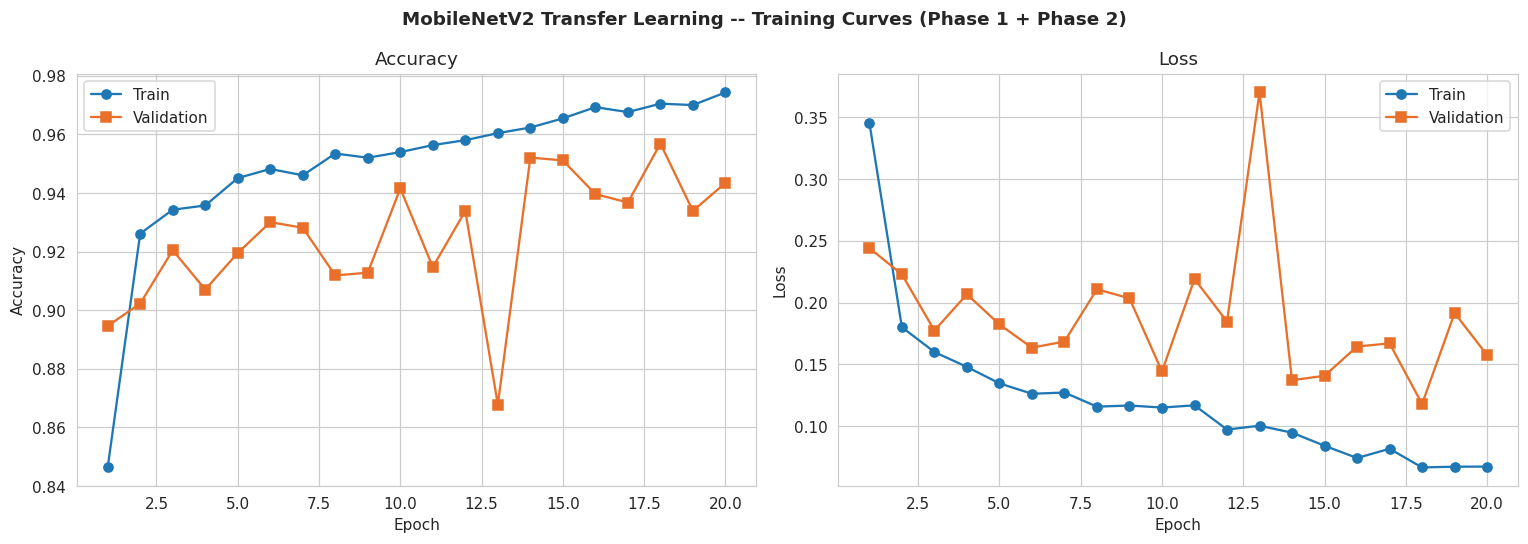

In [27]:
# Training curves (PDF). plot_training_curves saves by file extension -> .pdf.
history_mnet = merge_histories(history_mnet1.history, history_mnet2.history)
mnet_curves_pdf = os.path.join(FIG_DIR, "mobilenetv2_training_curves.pdf")
plot_training_curves(
    history_mnet,
    "MobileNetV2 Transfer Learning -- Training Curves (Phase 1 + Phase 2)",
    mnet_curves_pdf,
)
SAVED_PDFS.append(mnet_curves_pdf)

20/20 ━━━━━━━━━━━━━━━━━━━━ 16s 584ms/step

===== MobileNetV2 -- Test Classification Report =====
              precision    recall  f1-score   support

      NORMAL     0.9108    0.8291    0.8680       234
   PNEUMONIA     0.9027    0.9513    0.9263       390

    accuracy                         0.9054       624
   macro avg     0.9067    0.8902    0.8972       624
weighted avg     0.9057    0.9054    0.9045       624

Accuracy : 0.9054
Precision: 0.9027
Recall   : 0.9513   <-- primary clinical metric (sensitivity)
F1-score : 0.9263
AUC      : 0.9699


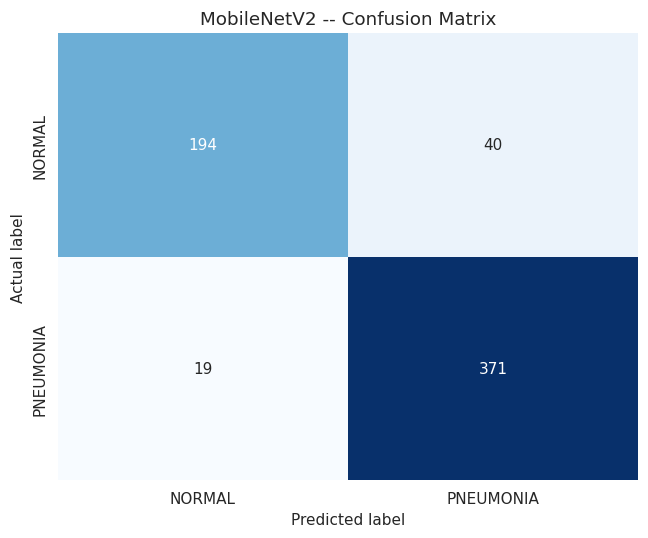

In [28]:
# Evaluate on the test set (reuses the shared evaluate_model -> CM saved as PDF).
mnet_cm_pdf = os.path.join(FIG_DIR, "mobilenetv2_confusion_matrix.pdf")
mobilenet_results = evaluate_model(MOBILENET_CKPT, test_gen, "MobileNetV2", mnet_cm_pdf)
SAVED_PDFS.append(mnet_cm_pdf)

### 13.2 - Updated Model Comparison (3 Models)


===== Model comparison (3 models, test set) =====
             Accuracy  Precision  Recall      F1     AUC
Model                                                   
Custom CNN     0.6250     0.6250  1.0000  0.7692  0.9141
VGG16          0.9167     0.9005  0.9744  0.9360  0.9688
MobileNetV2    0.9054     0.9027  0.9513  0.9263  0.9699


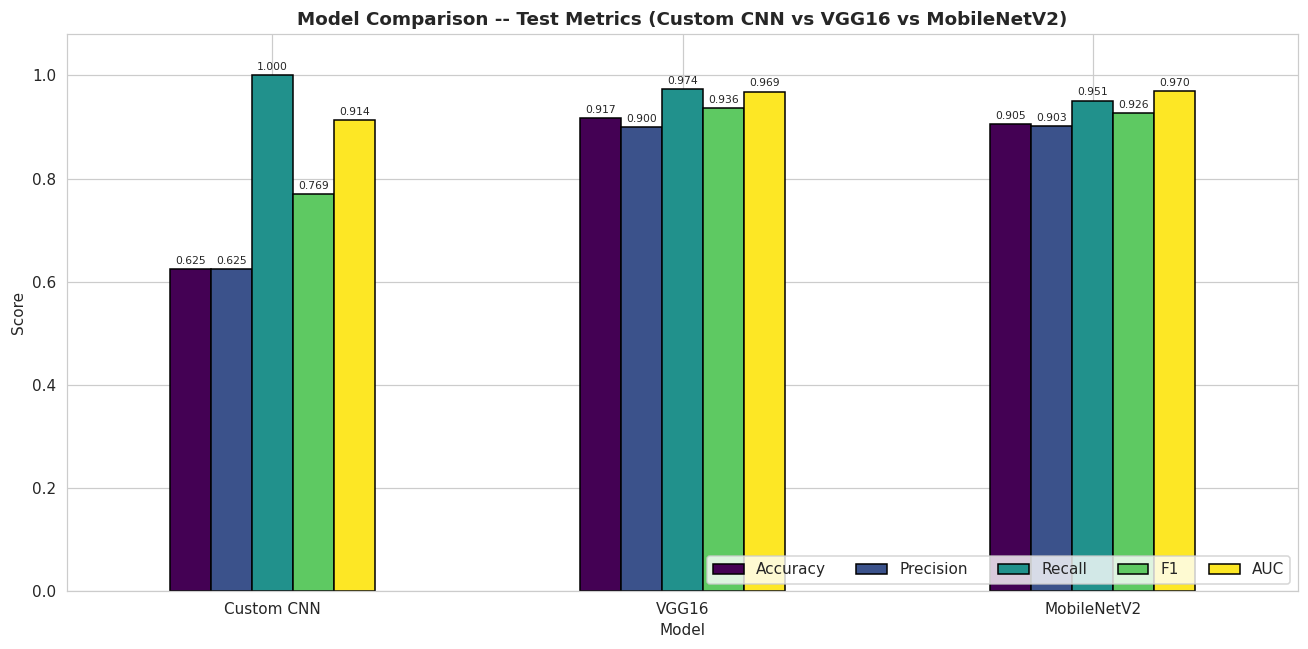

In [29]:
metric_cols = ["Accuracy", "Precision", "Recall", "F1", "AUC"]
all_results = [custom_results, vgg_results, mobilenet_results]
comparison_df = pd.DataFrame(
    [{k: r[k] for k in ["Model"] + metric_cols} for r in all_results]
).set_index("Model")
print("\n===== Model comparison (3 models, test set) =====")
print(comparison_df.round(4))

ax = comparison_df.plot(kind="bar", figsize=(12, 6), rot=0,
                        colormap="viridis", edgecolor="black")
ax.set_title("Model Comparison -- Test Metrics (Custom CNN vs VGG16 vs MobileNetV2)",
             fontweight="bold")
ax.set_ylabel("Score"); ax.set_ylim(0, 1.08)
ax.legend(loc="lower right", ncol=len(metric_cols))
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", fontsize=7, padding=2)
plt.tight_layout()
cmp_pdf = os.path.join(FIG_DIR, "model_comparison.pdf")
plt.savefig(cmp_pdf, format="pdf", dpi=300, bbox_inches="tight")
SAVED_PDFS.append(cmp_pdf)
plt.show()

### 13.3 - SHAP (Explainable AI): all three models

TF 2.19 uses **Keras 3**, where SHAP's `GradientExplainer` is frequently incompatible.
We therefore *attempt* `GradientExplainer` first and fall back to a backend-agnostic
**Partition explainer with an Image masker**, which treats each model as a black box
`f(images) -> P(class)` and works regardless of the Keras backend.

In [30]:
import subprocess, sys
try:
    import shap
except ImportError:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "shap"], check=True)
    import shap
print("shap version:", shap.__version__)

def load_imgs(paths):
    # Load + rescale 1/255 exactly like the generators.
    paths = list(paths)
    assert len(paths) > 0, "load_imgs got an empty path list (no images selected)"
    arr = np.stack([
        tf.keras.preprocessing.image.img_to_array(
            tf.keras.preprocessing.image.load_img(p, target_size=IMG_SIZE, color_mode="rgb")
        ) / 255.0
        for p in paths
    ]).astype("float32")
    return arr

# Background set: 50 train images.
rng = np.random.default_rng(SEED)
bg_paths = rng.choice(train_df["filepath"].values,
                      size=min(50, len(train_df)), replace=False)
background = load_imgs(bg_paths)
print("background shape:", background.shape)

def _to_int_labels(a):
    # Robustly coerce labels to int 0/1, whether ints, floats, or the string
    # class names ('NORMAL'/'PNEUMONIA'). Prevents empty selections.
    a = np.asarray(a).ravel()
    if a.dtype.kind in "iuf":
        return a.astype(int)
    return np.array([CLASS_NAMES.index(x) if x in CLASS_NAMES else int(x) for x in a],
                    dtype=int)

def representative_indices(results, n_correct_each=2, total=8):
    yt = _to_int_labels(results["y_true"])
    yp = _to_int_labels(results["y_pred"])
    n_corrN = int(np.sum((yt == 0) & (yp == 0)))
    n_corrP = int(np.sum((yt == 1) & (yp == 1)))
    n_fp = int(np.sum((yt == 0) & (yp == 1)))
    n_fn = int(np.sum((yt == 1) & (yp == 0)))
    print(f"  [select] n={len(yt)} correctNORMAL={n_corrN} correctPNEUMONIA={n_corrP} "
          f"FP={n_fp} FN={n_fn}")
    sel = []
    for cls in (0, 1):
        ok = np.where((yt == cls) & (yp == cls))[0]
        if len(ok):
            sel += list(rng.choice(ok, size=min(n_correct_each, len(ok)), replace=False))
    for mask in ((yt == 0) & (yp == 1), (yt == 1) & (yp == 0)):   # FP, FN
        idx = np.where(mask)[0]
        if len(idx):
            sel.append(int(rng.choice(idx)))
    sel = list(dict.fromkeys(int(i) for i in sel))
    if not sel:
        sel = list(range(min(total, len(yt))))
    return sel[:total]

shap version: 0.51.0
background shape: (50, 224, 224, 3)


  [select] n=624 correctNORMAL=0 correctPNEUMONIA=390 FP=234 FN=0


  0%|          | 0/1498 [00:00<?, ?it/s]

PartitionExplainer explainer:  33%|███▎      | 1/3 [00:00<?, ?it/s]

  0%|          | 0/1498 [00:00<?, ?it/s]

PartitionExplainer explainer: 100%|██████████| 3/3 [01:49<00:00, 21.23s/it]

  0%|          | 0/1498 [00:00<?, ?it/s]

PartitionExplainer explainer: 4it [02:40, 53.36s/it]                       


saved: /kaggle/working/figures/shap_custom_cnn.pdf | explained: ['T=PNEUMONIA/P=PNEUMONIA', 'T=PNEUMONIA/P=PNEUMONIA', 'T=NORMAL/P=PNEUMONIA']


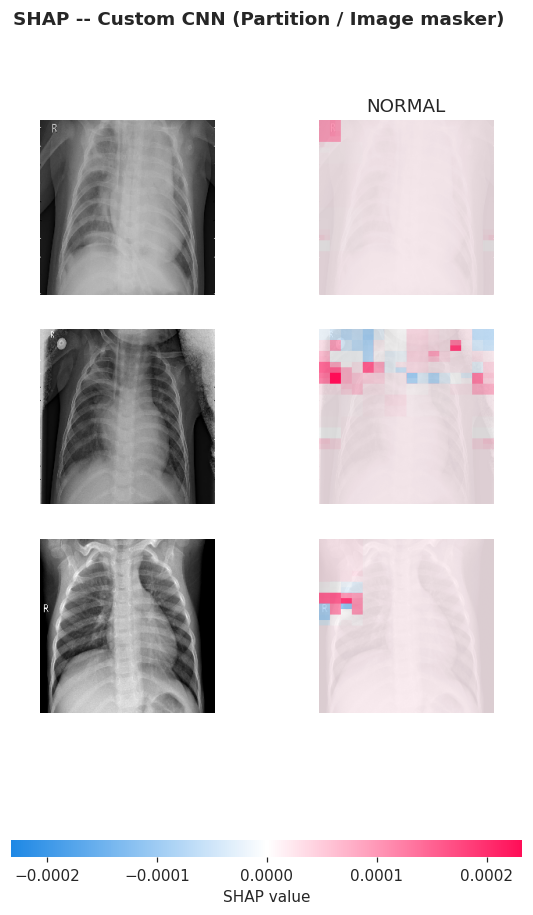

  [select] n=624 correctNORMAL=192 correctPNEUMONIA=380 FP=42 FN=10


  0%|          | 0/1498 [00:00<?, ?it/s]

PartitionExplainer explainer:  17%|█▋        | 1/6 [00:00<?, ?it/s]

  0%|          | 0/1498 [00:00<?, ?it/s]

PartitionExplainer explainer:  50%|█████     | 3/6 [01:40<01:02, 20.89s/it]

...

  0%|          | 0/1498 [00:00<?, ?it/s]

PartitionExplainer explainer: 100%|██████████| 6/6 [04:29<00:00, 47.23s/it]

  0%|          | 0/1498 [00:00<?, ?it/s]

PartitionExplainer explainer: 7it [05:31, 55.26s/it]                       


saved: /kaggle/working/figures/shap_vgg16.pdf | explained: ['T=NORMAL/P=NORMAL', 'T=NORMAL/P=NORMAL', 'T=PNEUMONIA/P=PNEUMONIA', 'T=PNEUMONIA/P=PNEUMONIA', 'T=NORMAL/P=PNEUMONIA', 'T=PNEUMONIA/P=NORMAL']


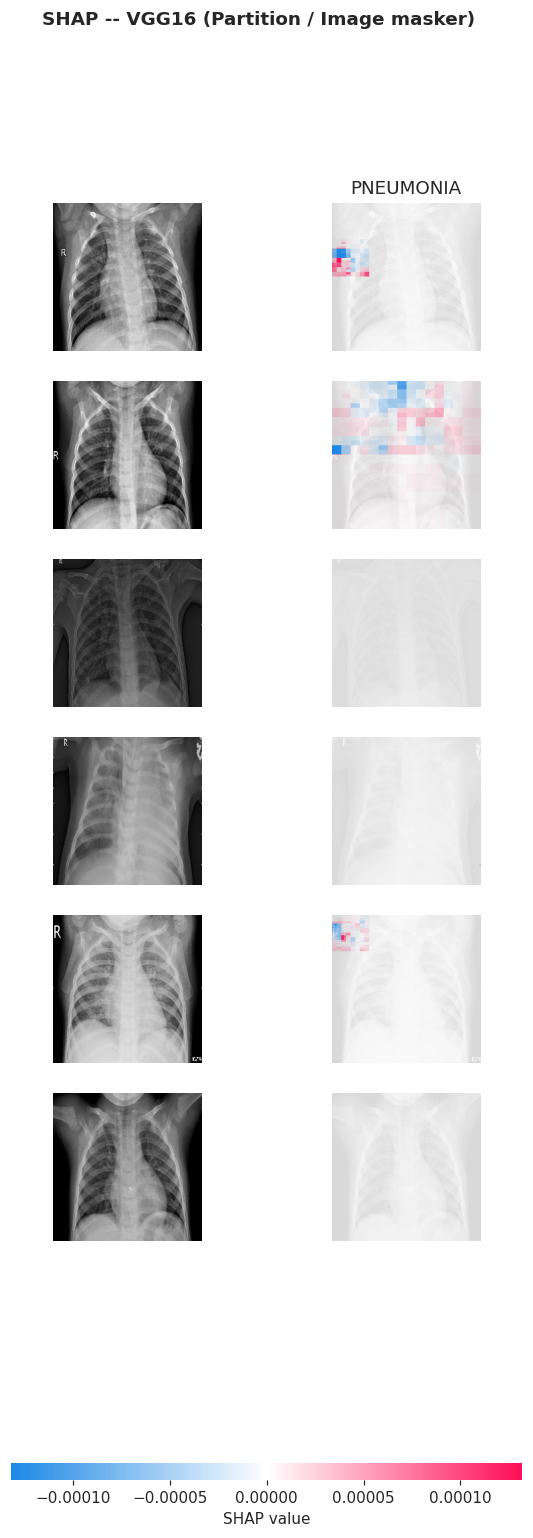

  [select] n=624 correctNORMAL=194 correctPNEUMONIA=371 FP=40 FN=19


  0%|          | 0/1498 [00:00<?, ?it/s]

PartitionExplainer explainer:  17%|█▋        | 1/6 [00:00<?, ?it/s]

  0%|          | 0/1498 [00:00<?, ?it/s]

PartitionExplainer explainer:  50%|█████     | 3/6 [01:53<01:03, 21.04s/it]

...

  0%|          | 0/1498 [00:00<?, ?it/s]

PartitionExplainer explainer: 100%|██████████| 6/6 [04:45<00:00, 48.67s/it]

  0%|          | 0/1498 [00:00<?, ?it/s]

PartitionExplainer explainer: 7it [05:41, 56.85s/it]                       


saved: /kaggle/working/figures/shap_mobilenetv2.pdf | explained: ['T=NORMAL/P=NORMAL', 'T=NORMAL/P=NORMAL', 'T=PNEUMONIA/P=PNEUMONIA', 'T=PNEUMONIA/P=PNEUMONIA', 'T=NORMAL/P=PNEUMONIA', 'T=PNEUMONIA/P=NORMAL']


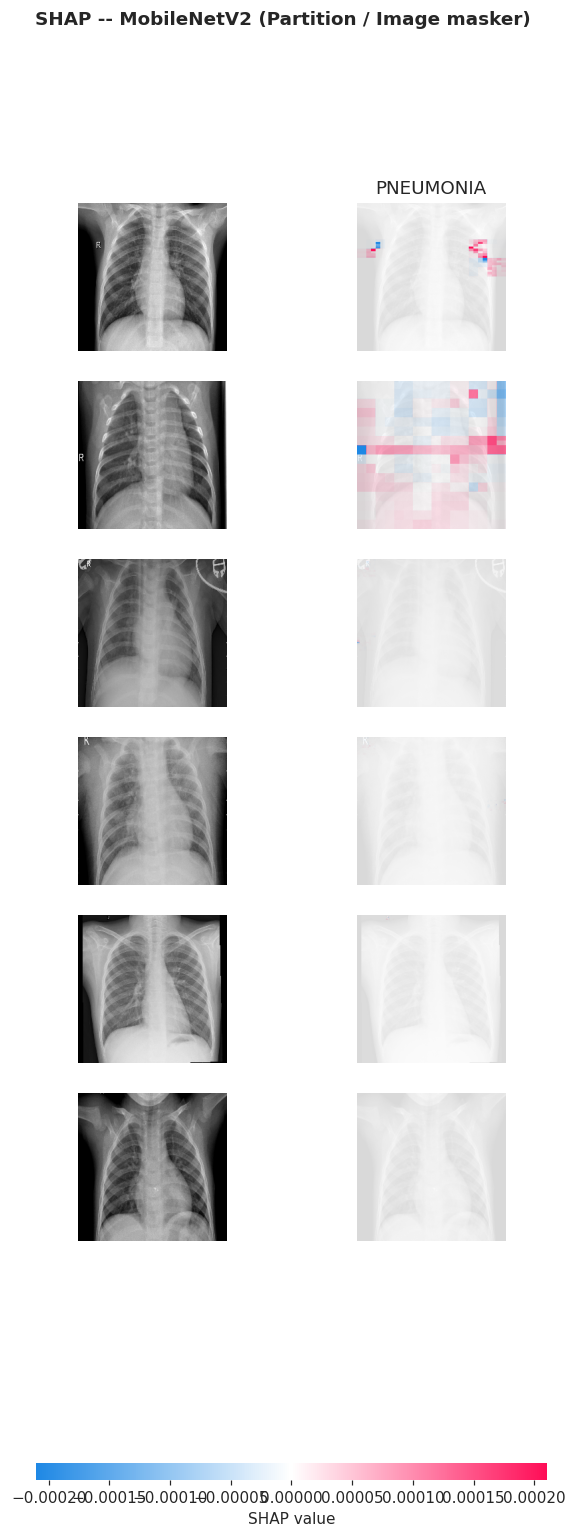

In [31]:
def shap_explain_and_save(model, model_name, results, fname, max_evals=1500):
    sel = representative_indices(results)
    paths = test_df.iloc[sel]["filepath"].values
    imgs = load_imgs(paths)
    yt = _to_int_labels(results["y_true"]); yp = _to_int_labels(results["y_pred"])
    titles = [f"T={CLASS_NAMES[yt[i]]}/P={CLASS_NAMES[yp[i]]}" for i in sel]

    def f(x):
        # 2-column class probabilities so SHAP labels NORMAL / PNEUMONIA.
        p = model.predict(x, verbose=0).ravel()
        return np.stack([1.0 - p, p], axis=1)

    # METHOD: SHAP Partition explainer with an Image masker -- treats each model as
    # a black box f(images) -> [P(NORMAL), P(PNEUMONIA)]. We deliberately do NOT use
    # GradientExplainer: on Keras 3 / TF 2.19 it runs without raising but returns
    # near-zero (blank/black) attributions, so its maps are not usable. The Partition
    # explainer is backend-agnostic and produces clean, interpretable overlays.
    masker = shap.maskers.Image("inpaint_telea", imgs[0].shape)
    explainer = shap.Explainer(f, masker, output_names=CLASS_NAMES)
    sv = explainer(imgs, max_evals=max_evals, batch_size=50,
                   outputs=shap.Explanation.argsort.flip[:1])   # explain top predicted class

    shap.image_plot(sv, show=False)
    fig = plt.gcf()
    fig.suptitle(f"SHAP -- {model_name} (Partition / Image masker)", fontweight="bold")
    path = os.path.join(FIG_DIR, fname)
    fig.savefig(path, format="pdf", dpi=300, bbox_inches="tight")
    SAVED_PDFS.append(path)
    print("saved:", path, "| explained:", titles)
    plt.show()

shap_explain_and_save(load_model(CUSTOM_CKPT),    "Custom CNN",  custom_results,    "shap_custom_cnn.pdf")
shap_explain_and_save(load_model(VGG_CKPT),       "VGG16",       vgg_results,       "shap_vgg16.pdf")
shap_explain_and_save(load_model(MOBILENET_CKPT), "MobileNetV2", mobilenet_results, "shap_mobilenetv2.pdf")

### 13.4 - Efficiency / Deployment Metrics (all three models)

Total/trainable parameters, on-disk model size, **real** training wall-time (from the
`TimingCallback`), single-image inference latency (batch=1, averaged over >=100 images
after warm-up) and throughput.


===== Efficiency / deployment metrics =====
             Total params  Trainable params  Model size (MB)  Train time (s)  \
Model                                                                          
Custom CNN         522433            521473             6.06           919.6   
VGG16            14846273           7211009           111.75          1650.7   
MobileNetV2       2586177           1676673            23.23          1650.3   

             Inference / img (ms)  Throughput (img/s)  
Model                                                  
Custom CNN                  17.03                58.7  
VGG16                       24.17                41.4  
MobileNetV2                129.49                 7.7  
saved: /kaggle/working/efficiency_metrics.csv


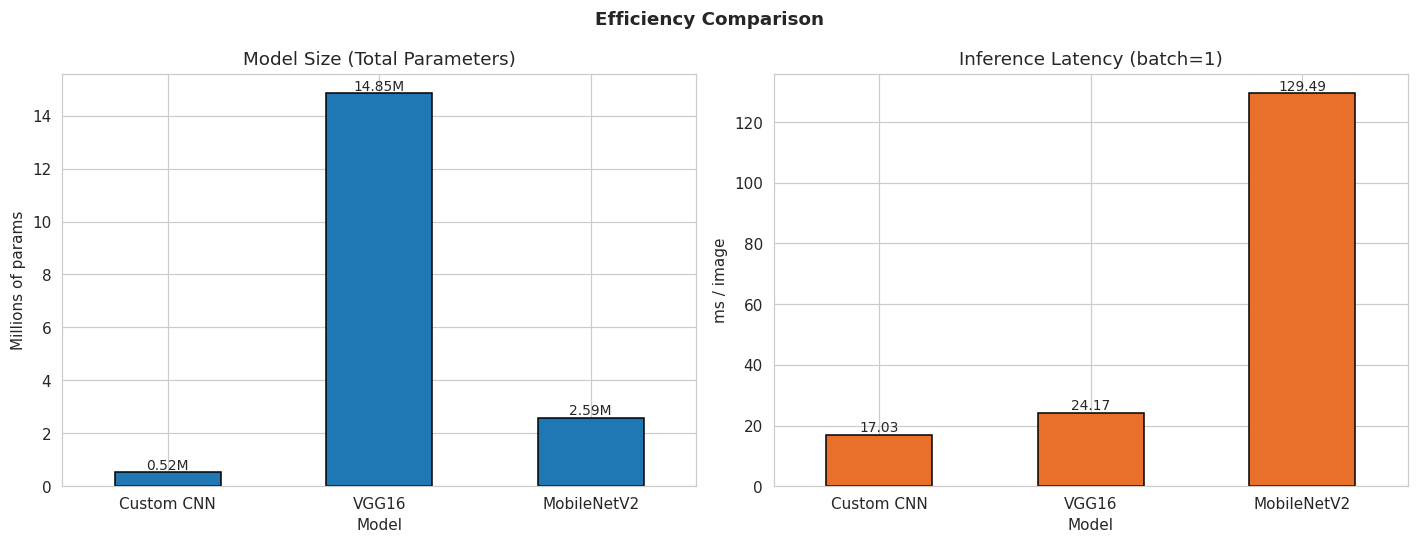

In [32]:
MODELS_META = [
    ("Custom CNN",  CUSTOM_CKPT),
    ("VGG16",       VGG_CKPT),
    ("MobileNetV2", MOBILENET_CKPT),
]

def trainable_param_count(model):
    return int(sum(np.prod(w.shape) for w in model.trainable_weights))

# Preload up to 100 test images once for batch=1 latency timing.
infer_imgs = load_imgs(test_df["filepath"].values[:100])

eff_rows = []
for name, ckpt in MODELS_META:
    model = load_model(ckpt)
    total_p = int(model.count_params())
    train_p = trainable_param_count(model)
    size_mb = os.path.getsize(ckpt) / (1024 * 1024)
    train_t = TRAIN_TIMES.get(name, float("nan"))   # seconds (summed over phases)

    for k in range(10):                              # warm-up
        _ = model(infer_imgs[k:k+1], training=False)
    t0 = time.perf_counter()
    for k in range(len(infer_imgs)):                 # batch=1 timing
        _ = model(infer_imgs[k:k+1], training=False)
    elapsed = time.perf_counter() - t0
    per_img_ms = (elapsed / len(infer_imgs)) * 1000.0
    throughput = len(infer_imgs) / elapsed

    eff_rows.append({
        "Model": name,
        "Total params": total_p,
        "Trainable params": train_p,
        "Model size (MB)": round(size_mb, 2),
        "Train time (s)": (round(train_t, 1) if train_t == train_t else float("nan")),
        "Inference / img (ms)": round(per_img_ms, 2),
        "Throughput (img/s)": round(throughput, 1),
    })

efficiency_df = pd.DataFrame(eff_rows).set_index("Model")
print("\n===== Efficiency / deployment metrics =====")
print(efficiency_df)

eff_csv = os.path.join(OUTPUT_DIR, "efficiency_metrics.csv")
efficiency_df.to_csv(eff_csv)
print("saved:", eff_csv)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
(efficiency_df["Total params"] / 1e6).plot(kind="bar", ax=axes[0],
        color=COLOR_NORMAL, edgecolor="black", rot=0)
axes[0].set_title("Model Size (Total Parameters)"); axes[0].set_ylabel("Millions of params")
for c in axes[0].containers: axes[0].bar_label(c, fmt="%.2fM", fontsize=9)
efficiency_df["Inference / img (ms)"].plot(kind="bar", ax=axes[1],
        color=COLOR_PNEUMONIA, edgecolor="black", rot=0)
axes[1].set_title("Inference Latency (batch=1)"); axes[1].set_ylabel("ms / image")
for c in axes[1].containers: axes[1].bar_label(c, fmt="%.2f", fontsize=9)
fig.suptitle("Efficiency Comparison", fontweight="bold")
fig.tight_layout()
eff_pdf = os.path.join(FIG_DIR, "efficiency_comparison.pdf")
fig.savefig(eff_pdf, format="pdf", dpi=300, bbox_inches="tight")
SAVED_PDFS.append(eff_pdf)
plt.show()

### 13.5 - Re-export Key Figures as Vector PDF (300 dpi)

The new template forbids PNG/JPEG (except screenshots). The matplotlib figures below
are regenerated from in-memory objects and saved as PDF.

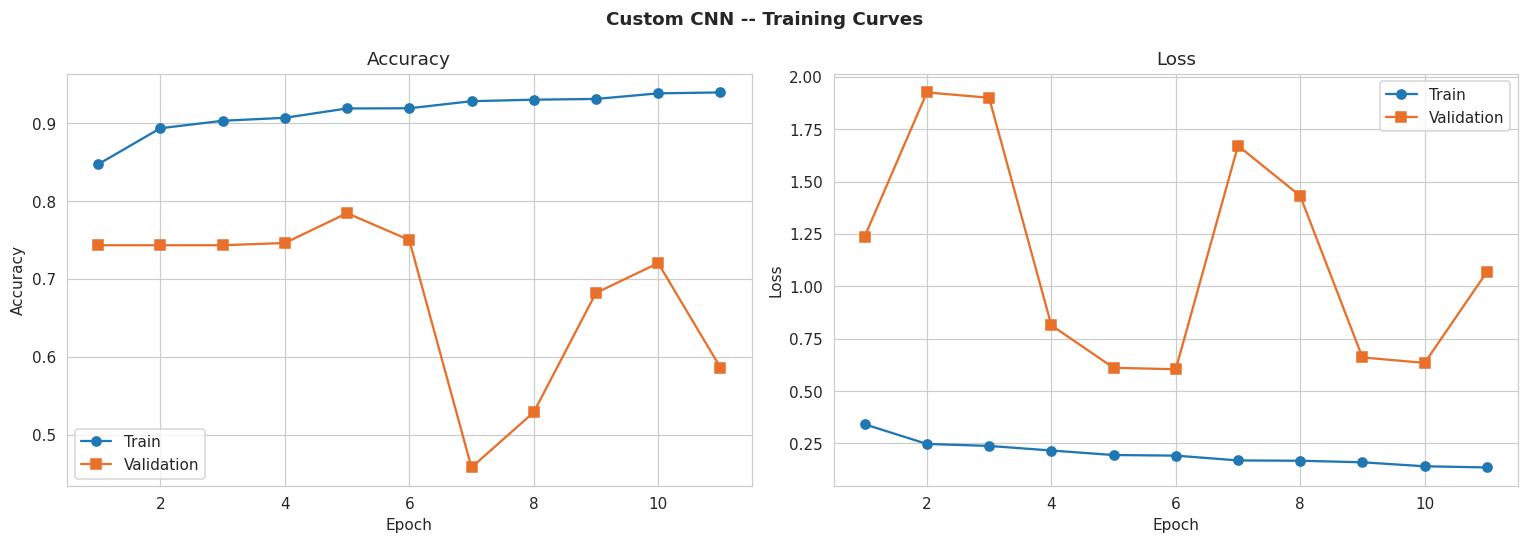

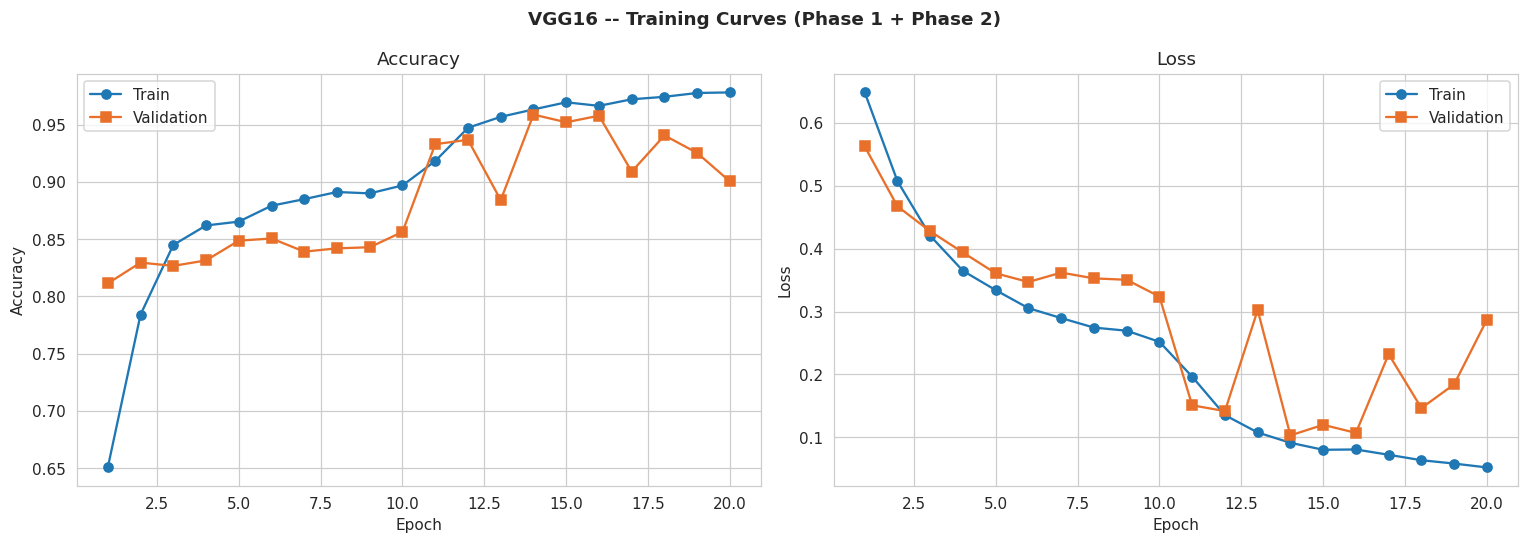

saved: /kaggle/working/figures/gradcam_visualization.pdf


In [33]:
def save_cm_pdf(results, fname):
    cm = confusion_matrix(results["y_true"], results["y_pred"])
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
    ax.set_xlabel("Predicted label"); ax.set_ylabel("Actual label")
    ax.set_title(f"{results['Model']} -- Confusion Matrix")
    fig.tight_layout()
    path = os.path.join(FIG_DIR, fname)
    fig.savefig(path, format="pdf", dpi=300, bbox_inches="tight")
    SAVED_PDFS.append(path); plt.close(fig)
    return path

# Training curves (PDF) from the in-memory history dicts.
for hist, title, fname in [
    (history_custom.history, "Custom CNN -- Training Curves", "custom_cnn_training_curves.pdf"),
    (history_vgg,            "VGG16 -- Training Curves (Phase 1 + Phase 2)", "vgg16_training_curves.pdf"),
]:
    p = os.path.join(FIG_DIR, fname)
    plot_training_curves(hist, title, p); SAVED_PDFS.append(p)

# Confusion matrices (PDF) for all three.
save_cm_pdf(custom_results,    "custom_cnn_confusion_matrix.pdf")
save_cm_pdf(vgg_results,       "vgg16_confusion_matrix.pdf")
save_cm_pdf(mobilenet_results, "mobilenetv2_confusion_matrix.pdf")

# Grad-CAM (PDF): re-save using the section-11 objects if still in memory.
try:
    fig = plt.figure(figsize=(8, 4 * len(selected)))
    axes = fig.subplots(len(selected), 2)
    if len(selected) == 1:
        axes = np.array([axes])
    for row, i in enumerate(selected):
        path = test_df.iloc[i]["filepath"]
        img = tf.keras.preprocessing.image.load_img(path, target_size=IMG_SIZE, color_mode="rgb")
        arr = np.expand_dims(tf.keras.preprocessing.image.img_to_array(img) / 255.0, 0)
        heatmap = make_gradcam_heatmap(arr, grad_model)
        original, overlay = overlay_heatmap(path, heatmap)
        truth, pred = CLASS_NAMES[y_true[i]], CLASS_NAMES[y_pred[i]]
        verdict = "correct" if y_true[i] == y_pred[i] else "MISCLASSIFIED"
        axes[row, 0].imshow(original); axes[row, 0].axis("off")
        axes[row, 0].set_title(f"Original\nTrue = {truth}", color=PALETTE[truth])
        axes[row, 1].imshow(overlay); axes[row, 1].axis("off")
        axes[row, 1].set_title(f"Grad-CAM ({verdict})\nPred = {pred}", color=PALETTE[pred])
    fig.suptitle(f"Grad-CAM -- {best['Model']} (last convolutional layer)", fontweight="bold")
    fig.tight_layout()
    gc_pdf = os.path.join(FIG_DIR, "gradcam_visualization.pdf")
    fig.savefig(gc_pdf, format="pdf", dpi=300, bbox_inches="tight")
    SAVED_PDFS.append(gc_pdf); plt.close(fig)
    print("saved:", gc_pdf)
except NameError as e:
    print("Grad-CAM objects not in memory; run section 11 first to export its PDF.", e)